Consultando el main.py del repo, una probabilidad cerca de 1 sería bonafide y cerca de 0 spoof.

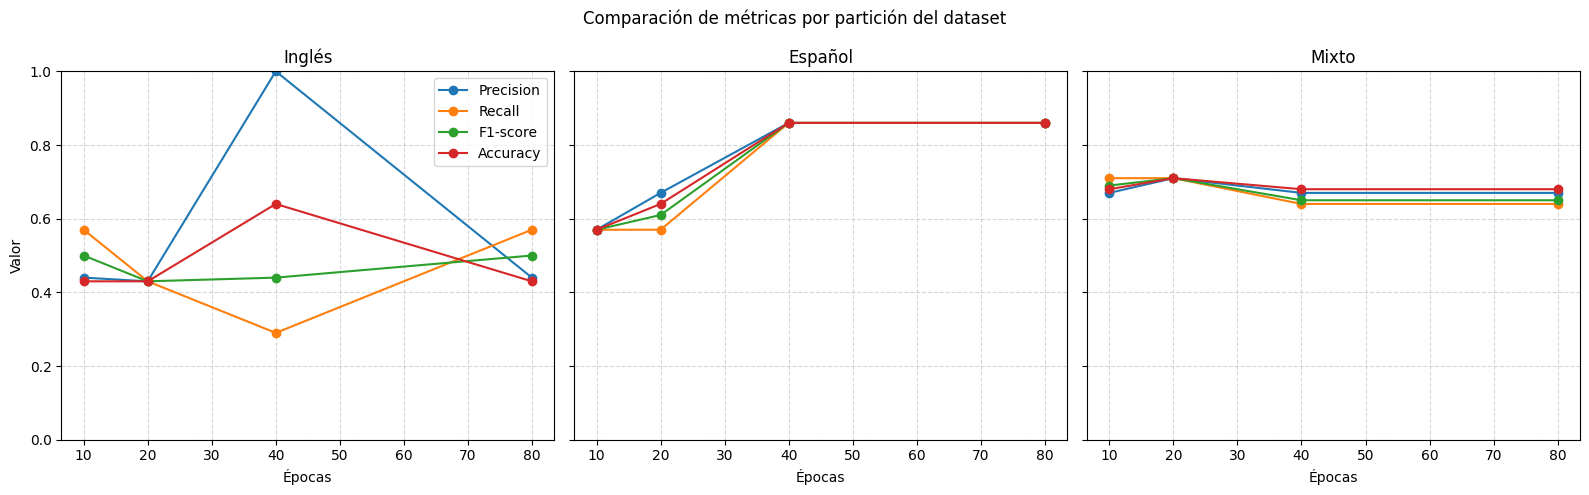

In [1]:
import matplotlib.pyplot as plt

# Épocas
epocas = [10, 20, 40, 80]

# Ejemplo de datos
datos = {
    'Inglés': {
        'accuracy':  [0.43, 0.43, 0.64, 0.43],
        'precision': [0.44, 0.43, 1, 0.44],
        'recall':    [0.57, 0.43, 0.29, 0.57],
        'f1':        [0.5, 0.43, 0.44, 0.5]
    },
    'Español': {
        'accuracy':  [0.57, 0.64, 0.86, 0.86],
        'precision': [0.57, 0.67, 0.86, 0.86],
        'recall':    [0.57, 0.57, 0.86, 0.86],
        'f1':        [0.57, 0.61, 0.86, 0.86]
    },
    'Mixto': {
        'accuracy':  [0.68, 0.71, 0.68, 0.68],
        'precision': [0.67, 0.71, 0.67, 0.67],
        'recall':    [0.71, 0.71, 0.64, 0.64],
        'f1':        [0.69, 0.71, 0.65, 0.65]
    }
}

fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (dataset, metricas) in zip(axs, datos.items()):
    ax.plot(epocas, metricas['precision'], marker='o', label='Precision')
    ax.plot(epocas, metricas['recall'], marker='o', label='Recall')
    ax.plot(epocas, metricas['f1'], marker='o', label='F1-score')
    ax.plot(epocas, metricas['accuracy'], marker='o', label='Accuracy')

    ax.set_title(dataset)
    ax.set_xlabel('Épocas')
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)

axs[0].set_ylabel('Valor')
axs[0].legend()

plt.suptitle('Comparación de métricas por partición del dataset')
plt.tight_layout()
plt.show()

# 1. IMPORTS

In [24]:
from __future__ import annotations
import re, ast, sys, csv
from pathlib import Path
from typing import Any, Dict
import numpy as np
import soundfile as sf
import torch
from scipy.signal import resample_poly
import torch.nn.functional as F
import librosa

# 2. RUTAS

In [25]:
REPO_DIR  = Path(r"C:\TFG\aasist") #ruta al repo AASIST
CONF_PATH = REPO_DIR / "config" / "AASIST.conf" #ruta al archivo de configuración
CKPT_PATH = REPO_DIR / "models" / "weights" / "AASIST.pth" #ruta al checkpoint del modelo  

INPUT_DIR = Path(r"C:\TFG\Datasets\Propio") #ruta a los audios
OUT_CSV   = Path(r"C:\TFG\Código\aasist_results2.csv") #ruta al csv de salida

print("CONF existe:", CONF_PATH.exists(), CONF_PATH)
print("CKPT existe:", CKPT_PATH.exists(), CKPT_PATH)

CONF existe: True C:\TFG\aasist\config\AASIST.conf
CKPT existe: True C:\TFG\aasist\models\weights\AASIST.pth


# 3. LEER CONF
El archivo .conf contiene arquitectura del modelo, parámetros de entrenamiento, dataset y su protocolo, preprocesado y checkpoints.

La función busca el elemento pasado por parámetro y devuelve el bloque superior que contiene ese elemento junto con los elementos al mismo nivel.

In [26]:
txt = CONF_PATH.read_text(encoding="utf-8", errors="ignore")

def extract_enclosing_dict(text: str, elem: str) -> str:
    i = text.find(elem)
    if i == -1:
        raise RuntimeError(f"No encuentro el elemento a buscar {elem!r} en el conf.")
    j = i
    while j >= 0 and text[j] != "{":
        j -= 1
    if j < 0:
        raise RuntimeError("No encuentro '{' antes del elem.")

    depth = 0
    in_str = False
    esc = False
    k = j
    while k < len(text):
        ch = text[k]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "{":
                
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    return text[j:k+1]
        k += 1
    raise RuntimeError("Error leyendo conf.")

# 4. CONSTUIR d_args
d_args contiene:
- first_conv: parámetros del primer bloque convolucional del modelo
- filts: estructura que marca cuántos filtros usa el modelo en cada bloque.
- gat_dims: dimensiones internas del embedding que representa cada nodo.
- pool_ratios: lista de ratios usados para pooling en las distintas fases.
- temperatures: controla lo suave o agresiva que es la atención en cada fase.

In [27]:
block = extract_enclosing_dict(txt, '"first_conv"')
block = re.sub(r",\s*(\}|\])", r"\1", block)  # quita comas colgantes
d_args: Dict[str, Any] = ast.literal_eval(block)

required = ["filts", "gat_dims", "pool_ratios", "temperatures", "first_conv"]
missing = [k for k in required if k not in d_args]
print("d_args listo. Características sin cargar:", missing)
if missing:
    raise RuntimeError("No se extrajo el dict correcto del conf.")

d_args listo. Características sin cargar: []


# 5. INSTANCIAR EL MODELO

In [28]:
if str(REPO_DIR) not in sys.path: 
    sys.path.insert(0, str(REPO_DIR)) #añade la raiz del repo al path

from models.AASIST import Model

device = "cpu"
model = Model(d_args).to(device).eval()
print("Modelo instanciado")

Modelo instanciado


# 6. CARGAR CHEKPOINT
El checkpoint sirve para cargar los pesos del entrenamiento

In [7]:
state = torch.load(str(CKPT_PATH), map_location=device)
if isinstance(state, dict):
    for key in ("state_dict", "model", "model_state_dict", "net"):
        if key in state and isinstance(state[key], dict):
            state = state[key]
            break

if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

missing_keys, unexpected_keys = model.load_state_dict(state, strict=False)
print(f"Checkpoint cargado (missing={len(missing_keys)}, unexpected={len(unexpected_keys)})")

Checkpoint cargado (missing=0, unexpected=0)


# 7. HELPERS DE AUDIO + VENTANA DESLIZANTE
Los helpers sirven para dejar los audios en un modelo estándar: mono(un canal), 16 Khz.
La ventana sirve para audios más largos de 4 segundos, los parte en ventanas de 4 segundos con solapamiento de dos para que no se quede información en el borde de una ventana.

In [29]:
def load_mono_16k(path, target_sr=16000):
    x, sr = sf.read(str(path), always_2d=False)
    x = x.astype(np.float32)
    if x.ndim > 1:
        x = np.mean(x, axis=1).astype(np.float32)
    if sr != target_sr:
        x = librosa.resample(x, orig_sr=sr, target_sr=target_sr).astype(np.float32)
    x = np.clip(x, -1.0, 1.0).astype(np.float32)

    return x


def make_windows(x: np.ndarray, sr=16000, win_sec=4.0, hop_sec=2.0):
    win = int(win_sec * sr)
    hop = int(hop_sec * sr)
    if len(x) <= win:
        y = np.zeros(win, dtype=np.float32)
        y[:len(x)] = x
        return [y]
    out=[]
    for s in range(0, len(x)-win+1, hop):
        out.append(x[s:s+win])
    if (len(x)-win) % hop != 0:
        out.append(x[-win:])
    return out

# 8. INFERENCIA

In [9]:
#Este hace media de probabilidades de todas las ventanas
@torch.no_grad()
def average_windows(wav: Path, win_sec=4.0, hop_sec=2.0):
    x = load_mono_16k(wav, 16000)
    ws = make_windows(x, 16000, win_sec, hop_sec)
    ps=[]
    for w in ws:
        t = torch.from_numpy(w).unsqueeze(0).to(device)  # (1,T)

        out = model(t)
        if isinstance(out, (tuple, list)):
            logits = next(o for o in out if torch.is_tensor(o) and o.ndim == 2 and o.shape[1] == 2)
        else:
            logits = out


        p1 = torch.softmax(logits, dim=1)[0,1].item()
        ps.append(p1)

    return float(np.mean(ps)), len(x)/16000.0, len(ws) #devuelve la probabilidad media contando todas las ventanas

In [10]:
#Este sería sin ventanas
from data_utils import pad 
CUT = 64600  # ~4.04s 

@torch.no_grad()
def score_without_windows(wav: Path):
    x = load_mono_16k(wav, 16000)              
    x4 = pad(x, CUT).astype(np.float32)  #ajusta el audio a la longitud que espera el modelo   

    t = torch.from_numpy(x4).unsqueeze(0).to(device) #convierte el audio a tensor 

    out = model(t)
    if isinstance(out, (tuple, list)):
        logits = next(o for o in out if torch.is_tensor(o) and o.ndim == 2 and o.shape[1] == 2)
    else:
        logits = out

    score_bonafide = logits[0, 1].item()

    prob_bonafide = F.softmax(logits, dim=1)[0, 1].item()

    duration_sec = len(x) / 16000.0
    return score_bonafide, prob_bonafide, duration_sec


In [11]:
#Este sumando los logists de todas las ventanas antes de hacer la media
from data_utils import pad 
CUT = 64600

@torch.no_grad()
def average_logits(wav: Path, win_sec=4.0, hop_sec=2.0):
    x = load_mono_16k(wav, 16000)
    ws = make_windows(x, 16000, win_sec, hop_sec)

    logits_sum = None

    for w in ws:
        w = pad(w, CUT).astype(np.float32)
        t = torch.from_numpy(w).unsqueeze(0).to(device)

        _, logits = model(t) 

        logits_sum = logits if logits_sum is None else logits_sum + logits

    prob_bona = F.softmax(logits_sum, dim=1)[0, 1].item()
    score_bona = logits_sum[0, 1].item() 

    return prob_bona, score_bona, len(x)/16000.0, len(ws)


# 9. TRATAR LOS AUDIOS

In [12]:
files = sorted(INPUT_DIR.rglob("*.wav"))
print("Audios encontrados:", len(files))
if not files:
    raise RuntimeError("No hay .wav en la ruta.")

with OUT_CSV.open("w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["filename", "prob1_mean", "duration_sec", "n_windows"])
    for i, fp in enumerate(files, 1):
        #p1, dur, nw = average_windows(fp, win_sec=4.0, hop_sec=2.0)
        #prob_bona, score_bona, dur, nw = average_logits(fp, win_sec=4.0, hop_sec=2.0)
        #w.writerow([str(fp), prob_bona, dur, nw])
        score_bona, prob_bona, dur = score_without_windows(fp)
        w.writerow([str(fp), prob_bona, dur])

print("Resultados en:", OUT_CSV)

Audios encontrados: 200
Resultados en: C:\TFG\Código\aasist_results2.csv


# Explicación de resultados
Vamos a ir explicando la arquitectura del modelo a la vez que intentamos ver que empuja al modelo a decidir la clasificación sacando los valores de sus técnicas.

Es importante mencionar que hay que ejecutar al menos las celda 1-5 y 7 de la aplicación del modelo, para poder ejecutar las celdas de explicabilidad.




In [30]:
from data_utils import pad
import matplotlib.pyplot as plt
from captum.attr import LayerIntegratedGradients
from captum.attr import IntegratedGradients

CUT = 64600 #número de muestras que espera el modelo (4.04s a 16kHz)
sr = 16000  #número de muestras por segundo 
bin_ms = 10         #tamaaño de cada bloque
bin_len = int(sr * bin_ms / 1000) #numero de muestras

audio = Path(r"C:\TFG\Datasets\Propio\Generado\Español\E_1_G.wav") 

def ret_model(t):
    with torch.no_grad(): #permite ejecutar más rapido y de forma menos costosa en memoria ya que no se necesitan los gradientes para la inferencia
        return model(t) 
    
def normalize_audio(wav_path = audio, target_sr = 16000):
    #normalizas y adaptas el audio como en las funciones de inferencia
    x = load_mono_16k(wav_path, target_sr)
    x4 = pad(x, CUT).astype(np.float32) #ajusta el audio a la longitud que espera el modelo  
    t = torch.from_numpy(x4).unsqueeze(0).to(device) #convierte el audio a tensor 
    return x, x4, t

def group_frecs(filts, bin_size = 160):
    #agrupamos muestras en T bloques de unos 10ms cada una
    num_bloques = filts.shape[1] // bin_size
    #primero reorganizamos con reshape y luego hacemos la media de cada bloque(160 muestras)
    filts_bin = filts[:, :num_bloques*bin_size].reshape(filts.shape[0], num_bloques, bin_size).mean(axis=2)

    #normalizamos cada filtro dividiendo por su valor máximo para no ocultar filtros debiles
    filts_norm = filts_bin / (filts_bin.max(axis=1, keepdims=True) + 1e-8)
    return filts_bin, filts_norm

x, x4, t = normalize_audio()
last_hidden, logits = ret_model(t)
long_audio = len(x)


El valor 0 de la tupla logits indica spoof mientras que el valor 1 indica bonafide. Cuanta mayor la diferencia, más seguro está el modelo de la clasificación del modelo.

Los valores de att sirven para ver el funcionamiento interno del modelo. Las salidas de la parte espectral nos permiten ver que hay 23(el número de la segunda y tercera posición) nodos y 29 nodos temporales.

Por último, estos valores sirven para ver como funciona el pooling simulando escoger los mejores 5 valores de cada grafo.

In [31]:
print("logits:", logits[0].cpu().numpy())
#espectral
att_S = model.GAT_layer_S.last_att_map      
pool_S = model.pool_S.last_scores.squeeze(-1)
#temporal
att_T = model.GAT_layer_T.last_att_map      
pool_T = model.pool_T.last_scores.squeeze(-1)

print("att_S shape:", att_S.shape)
print("att_T shape:", att_T.shape)

topS = torch.topk(pool_S[0], k=5)
topT = torch.topk(pool_T[0], k=5)

print("Top nodos espectrales:", topS.indices.cpu().numpy())
print("Scores espectrales:", topS.values.cpu().numpy())

print("Top nodos temporales:", topT.indices.cpu().numpy())
print("Scores temporales:", topT.values.cpu().numpy())

logits: [-0.5204506  -0.04844835]
att_S shape: torch.Size([1, 23, 23, 1])
att_T shape: torch.Size([1, 29, 29, 1])
Top nodos espectrales: [ 1  6 20  4  3]
Scores espectrales: [0.7764369  0.75366443 0.7220043  0.6866441  0.6768528 ]
Top nodos temporales: [ 4 17 19 20 21]
Scores temporales: [0.564385   0.56427574 0.56409615 0.56409174 0.56408477]


En esta celda, mostramos los valores de los 5 parámetros que conforman la última capa de salida(last_hidden)

weights contiene los pesos que convierten a last_hidden en el logit. Para sacar la contribución de cada clase, haces el producto escalar entre los pesos de ese bloque y el vector real.

Este celda solo nos sirve para sacar unas primeras conclusiones sobre si el modelo se ha basado más en el aspecto temporal o en el espectral y si el stack node es relevante.

In [10]:
weights = model.out_layer.weight.detach()      

d = weights.shape[1] // 5

blocks = {
    "T_max": last_hidden[:, 0:d],
    "T_avg": last_hidden[:, d:2*d],
    "S_max": last_hidden[:, 2*d:3*d],
    "S_avg": last_hidden[:, 3*d:4*d],
    "s_node": last_hidden[:, 4*d:5*d],
}

print("Contribuciones a los logits por bloque:")
for cls in [0, 1]:
    print(f"\nClase {cls}")
    for i, name in enumerate(blocks.keys()):
        w_block = weights[cls, i*d:(i+1)*d]
        x_block = blocks[name][0]
        contrib = torch.dot(w_block, x_block).item()
        print(f"{name}: {contrib:.4f}")
    if(cls == 0):
        print(f"Logit total spoof: {logits[0, cls].item():.4f}")
    else:
        print(f"Logit total bonafide: {logits[0, cls].item():.4f}")

Contribuciones a los logits por bloque:

Clase 0
T_max: -0.1000
T_avg: -0.0270
S_max: -0.0335
S_avg: 0.0451
s_node: 0.0700
Logit total spoof: -0.0018

Clase 1
T_max: -0.0375
T_avg: -0.0324
S_max: 0.1099
S_avg: -0.0047
s_node: -0.0927
Logit total bonafide: -0.0569


Vamos a mostrar en una gráfica la banda de frecuencias que capta cada filtro. Para eso usamos una FFT y obtenemos cuanto responde cada filtro a cada frecuencia. Podemos ver que los 70 filtros cubren todas las frecuencias de 0 a 8000 hz

In [11]:
bp = model.conv_time.band_pass.detach().cpu().numpy() #band_pass de la capa sinc-convolution

n_fft = 4096 #tamaño fft

# hacemos una fft(transformada rapida de fourier) para obtener la banda de frecuencias de cada filtro
fft = np.fft.rfft(bp, n=n_fft, axis=1)
mag = np.abs(fft)

freqs = np.fft.rfftfreq(n_fft, d=1/sr) #frecuencias correspondientes a cada bin de la fft

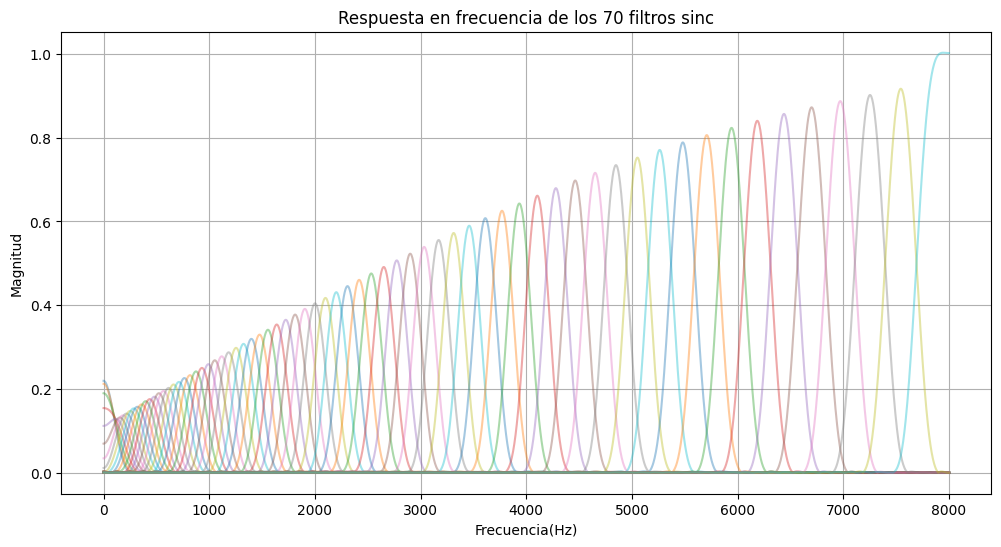

In [12]:
plt.figure(figsize=(12, 6))
for i in range(bp.shape[0]):
    plt.plot(freqs, mag[i], alpha=0.4)
plt.xlabel("Frecuencia(Hz)")
plt.ylabel("Magnitud")
plt.title("Respuesta en frecuencia de los 70 filtros sinc")
plt.grid(True)
plt.show()

En esta celda, vamos a guardar la salida de la primera capa del modelo, sinc-convolution, para ver que elementos se han activado más en este momento.
En la salida de esta primera celda, podemos ver que hay un solo audio(primer valor), 70 filtros(segundo valor) y cada filtro produce 64472 valores (tercer valor)

In [13]:
acts = {}

def save_sinc_conv_hook(module, inp, out):
    acts["sinc_conv"] = out.detach().cpu()

hook = model.conv_time.register_forward_hook(save_sinc_conv_hook) #esto es lo que nos permite guardar las activaciones de la capa

last_hidden, logits = ret_model(t) #es necesario volver a ejecutar el modelo para el hook

hook.remove() #eliminamos el hook para no que no afecte a futuras pruebas

sc_out = acts["sinc_conv"]   
print("Capa sinc_conv:", sc_out.shape)

Capa sinc_conv: torch.Size([1, 70, 64472])


Sacamos los valores minimos y máximos aproximados de cada filtro usando un umbral de un 50%. Además, sacamos el valor pico de cada filtro.

In [14]:
bands = []

for i in range(mag.shape[0]): #numero de filtros
    m = mag[i]
    thr = 0.5 * np.max(m)   #umbral(consideramos que la banda útil es solo la parte de la curva que supera al menos la mitad de su valor máximo)
    idx = np.where(m >= thr)[0]

    if len(idx) == 0:
        low_f, high_f = np.nan, np.nan
    else:
        low_f = freqs[idx[0]]
        high_f = freqs[idx[-1]]

    peak_f = freqs[np.argmax(m)]
    bands.append((i, low_f, peak_f, high_f))

for i, low_f, peak_f, high_f in bands:
    print(f"Filtro {i}: {low_f:.2f} Hz - {high_f:.2f} Hz (pico {peak_f:.2f} Hz)")

Filtro 0: 0.00 Hz - 113.28 Hz (pico 0.00 Hz)
Filtro 1: 0.00 Hz - 121.09 Hz (pico 0.00 Hz)
Filtro 2: 0.00 Hz - 140.62 Hz (pico 0.00 Hz)
Filtro 3: 0.00 Hz - 183.59 Hz (pico 0.00 Hz)
Filtro 4: 0.00 Hz - 234.38 Hz (pico 113.28 Hz)
Filtro 5: 0.00 Hz - 265.62 Hz (pico 156.25 Hz)
Filtro 6: 74.22 Hz - 296.88 Hz (pico 183.59 Hz)
Filtro 7: 105.47 Hz - 332.03 Hz (pico 218.75 Hz)
Filtro 8: 140.62 Hz - 363.28 Hz (pico 253.91 Hz)
Filtro 9: 175.78 Hz - 394.53 Hz (pico 285.16 Hz)
Filtro 10: 207.03 Hz - 433.59 Hz (pico 320.31 Hz)
Filtro 11: 246.09 Hz - 472.66 Hz (pico 359.38 Hz)
Filtro 12: 289.06 Hz - 507.81 Hz (pico 398.44 Hz)
Filtro 13: 324.22 Hz - 550.78 Hz (pico 437.50 Hz)
Filtro 14: 367.19 Hz - 593.75 Hz (pico 480.47 Hz)
Filtro 15: 414.06 Hz - 632.81 Hz (pico 523.44 Hz)
Filtro 16: 457.03 Hz - 679.69 Hz (pico 566.41 Hz)
Filtro 17: 503.91 Hz - 726.56 Hz (pico 617.19 Hz)
Filtro 18: 550.78 Hz - 773.44 Hz (pico 664.06 Hz)
Filtro 19: 597.66 Hz - 824.22 Hz (pico 710.94 Hz)
Filtro 20: 652.34 Hz - 875.00 H

Mostramos los audios que más se activan y sus valores aunque de momento no den información interpretable.

In [15]:
filt_score = sc_out.abs().mean(dim=2)[0].numpy() #hacemos la media de los valores absolutos de cada filtro a lo largo del tiempo 
# y quitamos la primera dimesión del array para quedarnos solo con estos valores

top_idx = np.argsort(filt_score)[::-1][:10]
print("Top 10 filtros más activos:", top_idx)
print("Puntuaciones:", filt_score[top_idx])

Top 10 filtros más activos: [ 7  8 17  6 16 18 12  9 13 11]
Puntuaciones: [0.00383862 0.00371556 0.00370969 0.00365824 0.00356471 0.00347904
 0.00347298 0.00346166 0.00340016 0.00335043]


Mostramos un gráfica centrandonos en los filtros que más se activan.

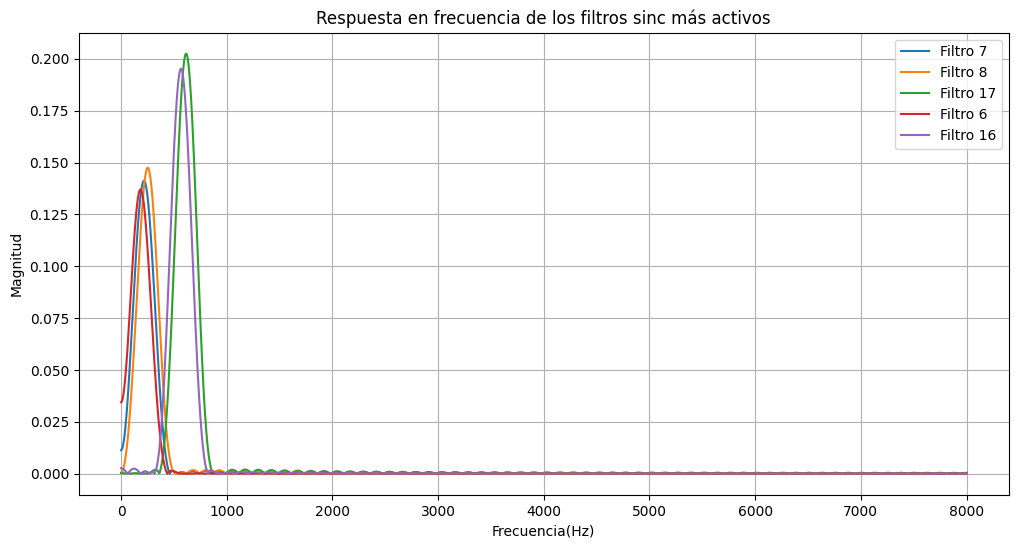

Filtro 7: 105.47 Hz - 332.03 Hz (pico 218.75 Hz)
Filtro 8: 140.62 Hz - 363.28 Hz (pico 253.91 Hz)
Filtro 17: 503.91 Hz - 726.56 Hz (pico 617.19 Hz)
Filtro 6: 74.22 Hz - 296.88 Hz (pico 183.59 Hz)
Filtro 16: 457.03 Hz - 679.69 Hz (pico 566.41 Hz)


In [16]:
top_filters = top_idx[:5]  # los 5 filtros más activos según la media de activación

plt.figure(figsize=(12, 6))
for i in top_filters:
    plt.plot(freqs, mag[i], label=f"Filtro {i}")
plt.xlabel("Frecuencia(Hz)")
plt.ylabel("Magnitud")
plt.title("Respuesta en frecuencia de los filtros sinc más activos")
plt.legend()
plt.grid(True)
plt.show()

for i in top_filters: #lo mismo que arriba pero solo para los filtros más activos
    m = mag[i]
    thr = 0.5 * np.max(m)
    idx = np.where(m >= thr)[0]
    low_f = freqs[idx[0]]
    high_f = freqs[idx[-1]]
    peak_f = freqs[np.argmax(m)]
    print(f"Filtro {i}: {low_f:.2f} Hz - {high_f:.2f} Hz (pico {peak_f:.2f} Hz)")

Creamos una gráfica que muestra la activación de los audios con mayor puntuación a lo largo del audio. Aqui podemos ver que los filtros no responden de manera uniforme durante todo el audio y zonas con nula actividad. El parecido entre las curvas de distintos filtros se puede explicar en que como veremos en la gráfica anterior, filtros consecutivos se pisan ciertas frecuencias por lo que tiene sentido que se activen a la vez.

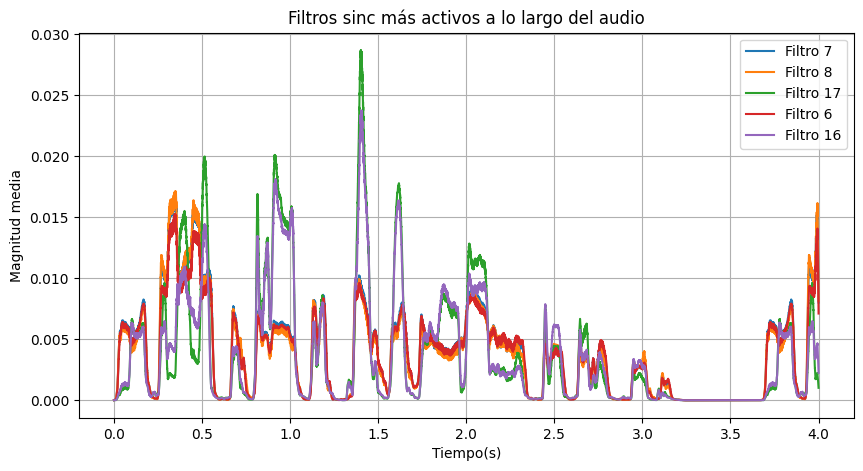

In [17]:
plt.figure(figsize=(10, 5))
for idx in top_idx[:5]:
    y = sc_out[0, idx].abs().numpy()
    #suavizado agrupando valores con vecinos como si de una ventana deslizante se tratara para ver mejor las tendencias a lo largo del tiempo
    #ayuda verlo porque sino se colorean el interior de las cuervas y no se distinguen bien
    k = 200
    y_smooth = np.convolve(y, np.ones(k)/k, mode="same")
    x_sec = np.linspace(0, 4.0, len(y))
    plt.plot(x_sec, y_smooth, label=f"Filtro {idx}")

plt.legend()
plt.title("Filtros sinc más activos a lo largo del audio")
plt.xlabel("Tiempo(s)")
plt.ylabel("Magnitud media")
plt.grid(True)
plt.show()

## OCCLUSION
Esta técnica consiste en ir "tapando" segmentos o partes de la entrada para ver como varía el logit. La acción de tapar varia según donde se aplica.

Primero, una función común que saca los logits de ambas clases, la probabilidad de la clase objetivo y esta clase objetivo si no se especifica.


In [21]:
def base_scores_logits(t, target_class=None):
    _, logits_ref = ret_model(t)
    prob_ref = torch.softmax(logits_ref, dim=1)
 
    if target_class is None:
        target_class = int(torch.argmax(prob_ref, dim=1).item())

    #valores base para comparar
    base_logit = float(logits_ref[0, target_class].item()) 
    base_prob = float(prob_ref[0, target_class].item())

    base_spoof = float(logits_ref[0, 0].item())
    base_bona  = float(logits_ref[0, 1].item())
    return base_logit, base_prob, base_spoof, base_bona, target_class

Ahora vamos a sacar que instantes de tiempo son más relevantes para el modelo a la hora de responder. Para ello, vamos tapando fragmentos del audio y vemos como afecta esto a la predicción.

In [19]:
def hiding_scan(target_class=None, occ_ms=200, hop_ms=50, fill_mode="zero"):
    base_logit, base_prob, base_spoof, base_bona, target_class = base_scores_logits(t)
    base_margin = base_spoof - base_bona
    #transformar los ms a muestras
    hid_len = int(sr * occ_ms / 1000)
    hop_len = int(sr * hop_ms / 1000)

    results = []

    for start in range(0, max(1, long_audio - hid_len + 1), hop_len):
        end = min(start + hid_len, long_audio)

        x_hid = x.copy()

        if fill_mode == "zero": #pone a cero el tramo tapado
            x_hid[start:end] = 0.0
        elif fill_mode == "mean": #sustituye por la media del audio
            x_hid[start:end] = np.mean(x_hid)
        else:
            raise ValueError("fill_mode debe ser zero o mean")

        #con el audio modificado, volvemos a calcular valores
        x_hid4 = pad(x_hid, CUT).astype(np.float32)
        t_hid = torch.from_numpy(x_hid4).unsqueeze(0).to(device)

        _, logits_hid = ret_model(t_hid)
        prob_hid = torch.softmax(logits_hid, dim=1)

        hid_logit = float(logits_hid[0, target_class].item())
        hid_prob = float(prob_hid[0, target_class].item())

        hid_spoof = float(logits_hid[0, 0].item())
        hid_bona = float(logits_hid[0, 1].item())
        hid_margin = hid_spoof - hid_bona

        results.append({
            "start_s": start / sr,
            "end_s": end / sr,
            "inc_logit": base_logit - hid_logit,
            "inc_prob": base_prob - hid_prob,
            "inc_margin": base_margin - hid_margin
        })

    return {
        "target_class": target_class,
        "base_logit": base_logit,
        "base_prob": base_prob,
        "results": results
    }

Sacamos dos valores, el logit y la probabilidad, que indican lo mismo, cuando tienen valores grandes(ese tramo es positivo a favor de esa clase y negativos lo contrario), afectan fuertemente al logit final y si están cerca de 0 afectan poco.

In [20]:
out = hiding_scan(
    target_class=None,   #usa la clase predicha, puedes fijarlo a 0 o 1 si quieres ver una salida en conreto
    occ_ms=bin_ms*5,       #tapa 50ms 
    hop_ms=bin_ms,         #avanza de 10 en 10 ms, mejor para ver cambios finos
    fill_mode="zero"
)

if(out["target_class"] == 0):
    print("Clase analizada: spoof")
else:
    print("Clase analizada: bona fide")

top = sorted(out["results"], key=lambda d: d["inc_logit"], reverse=True)[:5]
for r in top:
    print(r)

Clase analizada: spoof
{'start_s': 0.56, 'end_s': 0.61, 'inc_logit': 3.9462000131607056e-05, 'inc_prob': -1.4901161193847656e-06, 'inc_margin': -5.8300793170928955e-06}
{'start_s': 2.4, 'end_s': 2.45, 'inc_logit': 3.701820969581604e-05, 'inc_prob': 4.172325134277344e-07, 'inc_margin': 1.780688762664795e-06}
{'start_s': 0.0, 'end_s': 0.05, 'inc_logit': 2.269074320793152e-05, 'inc_prob': 5.125999450683594e-06, 'inc_margin': 2.0597130060195923e-05}
{'start_s': 0.02, 'end_s': 0.07, 'inc_logit': 2.2079795598983765e-05, 'inc_prob': 6.496906280517578e-06, 'inc_margin': 2.606213092803955e-05}
{'start_s': 1.2, 'end_s': 1.25, 'inc_logit': 2.195313572883606e-05, 'inc_prob': 8.404254913330078e-06, 'inc_margin': 3.378838300704956e-05}


Ahora graficamos la salida anterior lo que nos permite ver el audio en su conjunto y aunque no nos ayuda a saber que fenomenos son los que realmente empujan la decisión del modelo, si nos muestra donde están los fenómenos relevantes en el plano temporal.

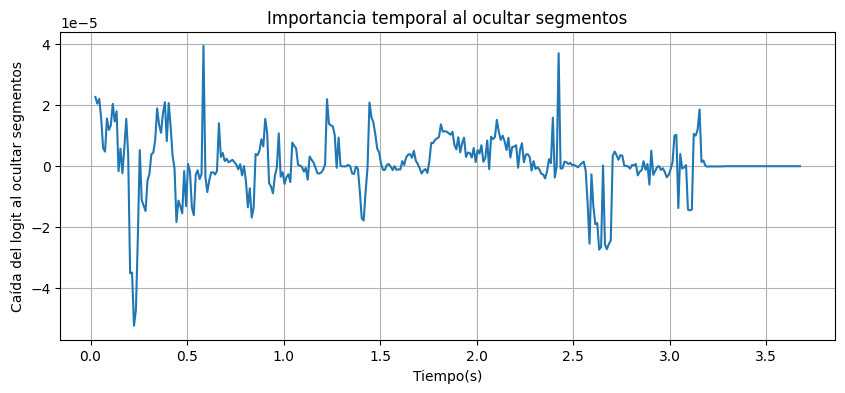

In [21]:
xs = [(r["start_s"] + r["end_s"]) / 2 for r in out["results"]] #dibujamos solo el punto medio de cada tramo
ys = [r["inc_logit"] for r in out["results"]]

plt.figure(figsize=(10,4))
plt.plot(xs, ys)
plt.xlabel("Tiempo(s)")
plt.ylabel("Caída del logit al ocultar segmentos")
plt.title("Importancia temporal al ocultar segmentos")
plt.grid(True)
plt.show()

Ahora, graficamos la diferencia entre el logit spoof y bona fide ya que puede haber casos que si en la gráfica de arriba vemos caer el logit de una clase mucho en cierto instante, podemos concluir que influye mucho. Sin embargo, con esta diferencia podemos ver si realmente la clase contraria ha crecido respecto a la objetivo o han descendido las dos y entonces el instante no es tan relevante como podía parecer en un primer momento.

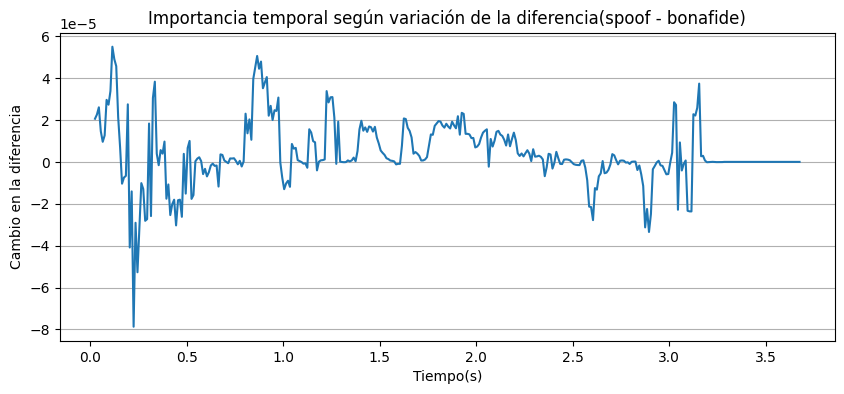

In [22]:
labels = [(r["start_s"] + r["end_s"]) / 2 for r in out["results"]] #dibujamos solo el punto medio de cada tramo
ys = [r["inc_margin"] for r in out["results"]]

plt.figure(figsize=(10, 4))
plt.plot(labels, ys)
plt.xlabel("Tiempo(s)")
plt.ylabel("Cambio en la diferencia")
plt.title("Importancia temporal según variación de la diferencia(spoof - bonafide)")
plt.grid(True, axis="y")
plt.show()

Hacemos un hiding similar al temporal pero para las bandas de frecuencia y obtenemos las que más aportan al logit. La única diferencia es tener que usar fft para ir cambiando entre el espacio temporal y el espectral.

In [ ]:
def hiding_scan_freq(target_class=None, n_bands=8, fmax=8000):
    base_logit, base_prob, base_spoof, base_bona, target_class = base_scores_logits(t)
    base_margin = base_spoof - base_bona
    #pasar el audio a frecuencia con una fft para poder manipular bandas de frecuencia
    X = np.fft.rfft(x) 
    freqs = np.fft.rfftfreq(long_audio, d=1/sr) #valor cada 0.25Hz con los valores actuales
    # bandas uniformes entre 0 y fmax
    band_edges = np.linspace(0, fmax, n_bands + 1)

    results = []

    for i in range(n_bands):
        f_low = band_edges[i]
        f_high = band_edges[i + 1]

        x_hidf = X.copy()
        #creamos una mascara con los valores entre esos parámetros
        band_mask = (freqs >= f_low) & (freqs < f_high)
        x_hidf[band_mask] = 0.0
        #volver a dominio temporal
        x_hidf = np.fft.irfft(x_hidf, n=long_audio).astype(np.float32)
        #limitamos las amplitudes por si acaso
        x_hidf = np.clip(x_hidf, -1.0, 1.0).astype(np.float32)
        #con el audio modificado, volvemos a calcular valores
        x4_hidf = pad(x_hidf, CUT).astype(np.float32)
        t_hidf = torch.from_numpy(x4_hidf).unsqueeze(0).to(device)

        _, logits_hidf = ret_model(t_hidf)
        prob_hidf = torch.softmax(logits_hidf, dim=1)

        hidf_logit = float(logits_hidf[0, target_class].item())
        hidf_prob = float(prob_hidf[0, target_class].item())

        hidf_spoof = float(logits_hidf[0, 0].item())
        hidf_bona = float(logits_hidf[0, 1].item())
        hidf_margin = hidf_spoof - hidf_bona

        results.append({
            "band_idx": i,
            "f_start": float(f_low),
            "f_end": float(f_high),
            "inc_logit": base_logit - hidf_logit,   # caída del logit al ocultar la banda
            "inc_prob": base_prob - hidf_prob,       # caída de la probabilidad
            "inc_margin": base_margin - hidf_margin
        })

    return {
        "target_class": target_class,
        "base_logit": base_logit,
        "base_prob": base_prob,
        "results": results
    }

In [28]:
out_freq = hiding_scan_freq(
    target_class=None,   #usa la clase predicha, puedes fijarlo a 0 o 1 si quieres ver una salida en conreto
    n_bands=10,
    fmax=8000
)

if out_freq["target_class"] == 0:
    print("Clase analizada: spoof")
else:
    print("Clase analizada: bona fide")

top = sorted(out_freq["results"], key=lambda d: d["inc_logit"], reverse=True)
for r in top:
    print(r)

Clase analizada: spoof
{'band_idx': 5, 'f_start': 4000.0, 'f_end': 4800.0, 'inc_logit': 2.6300549507141113e-06, 'inc_prob': 2.2649765014648438e-06, 'inc_margin': 9.141862392425537e-06}
{'band_idx': 4, 'f_start': 3200.0, 'f_end': 4000.0, 'inc_logit': 2.3730099201202393e-06, 'inc_prob': 1.7881393432617188e-07, 'inc_margin': 7.860362529754639e-07}
{'band_idx': 7, 'f_start': 5600.0, 'f_end': 6400.0, 'inc_logit': -8.456408977508545e-07, 'inc_prob': 1.0728836059570312e-06, 'inc_margin': 4.33996319770813e-06}
{'band_idx': 6, 'f_start': 4800.0, 'f_end': 5600.0, 'inc_logit': -1.0844320058822632e-05, 'inc_prob': 2.980232238769531e-07, 'inc_margin': 1.3187527656555176e-06}
{'band_idx': 3, 'f_start': 2400.0, 'f_end': 3200.0, 'inc_logit': -1.9453465938568115e-05, 'inc_prob': -2.2649765014648438e-06, 'inc_margin': -8.869916200637817e-06}
{'band_idx': 9, 'f_start': 7200.0, 'f_end': 8000.0, 'inc_logit': -2.6538968086242676e-05, 'inc_prob': -7.033348083496094e-06, 'inc_margin': -2.7939677238464355e-05}

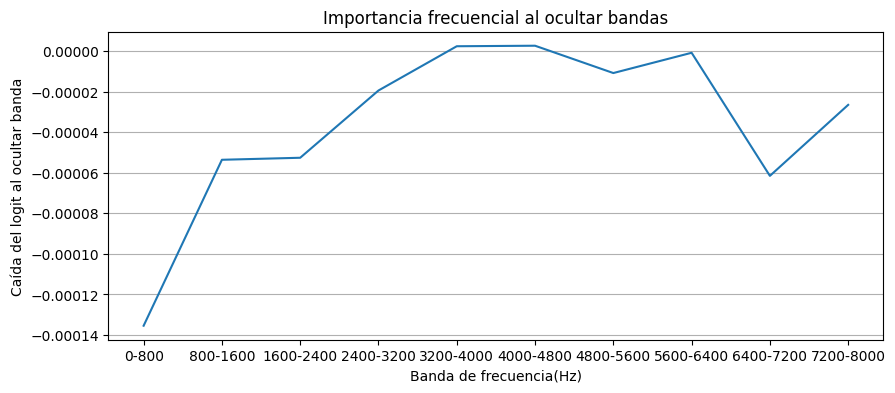

In [29]:
labels = [f'{int(r["f_start"])}-{int(r["f_end"])}' for r in out_freq["results"]]
ys = [r["inc_logit"] for r in out_freq["results"]]

plt.figure(figsize=(10, 4))
plt.plot(labels, ys)
plt.xlabel("Banda de frecuencia(Hz)")
plt.ylabel("Caída del logit al ocultar banda")
plt.title("Importancia frecuencial al ocultar bandas")
plt.grid(True, axis="y")
plt.show()

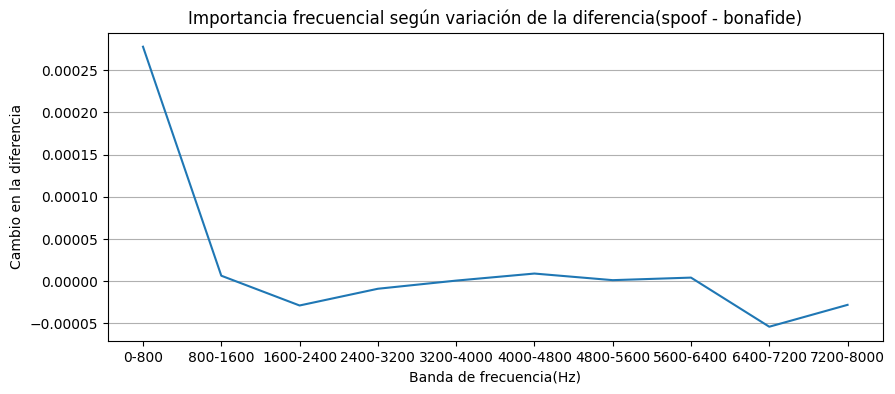

In [30]:
labels = [f'{int(r["f_start"])}-{int(r["f_end"])}' for r in out_freq["results"]]
ys = [r["inc_margin"] for r in out_freq["results"]]

plt.figure(figsize=(10, 4))
plt.plot(labels, ys)
plt.xlabel("Banda de frecuencia(Hz)")
plt.ylabel("Cambio en la diferencia")
plt.title("Importancia frecuencial según variación de la diferencia(spoof - bonafide)")
plt.grid(True, axis="y")
plt.show()

## MAPAS FILTRO-TIEMPO E INTEGRATED GRADIENTS

En esta celda, mostramos un mapa de activación de los filtros normalizados por su máximo y un mapa sin normalización. Los filtros asociados a bandas de frecuencia bajas están en la parte inferior del eje Y. Los mapas nos permite ver en que tramos del audio se activan más ciertos filtros y son una representación de como se ve la salida de la capa sinc-convolution. 

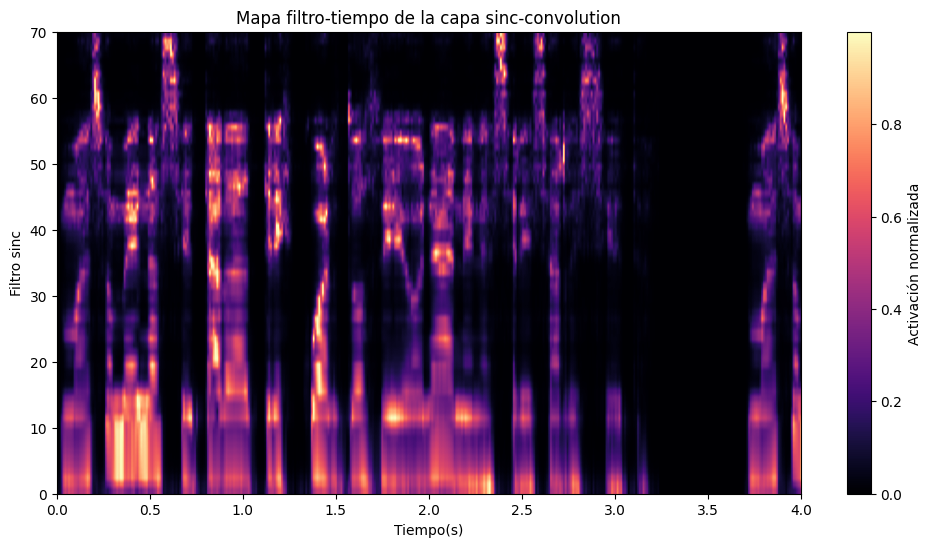

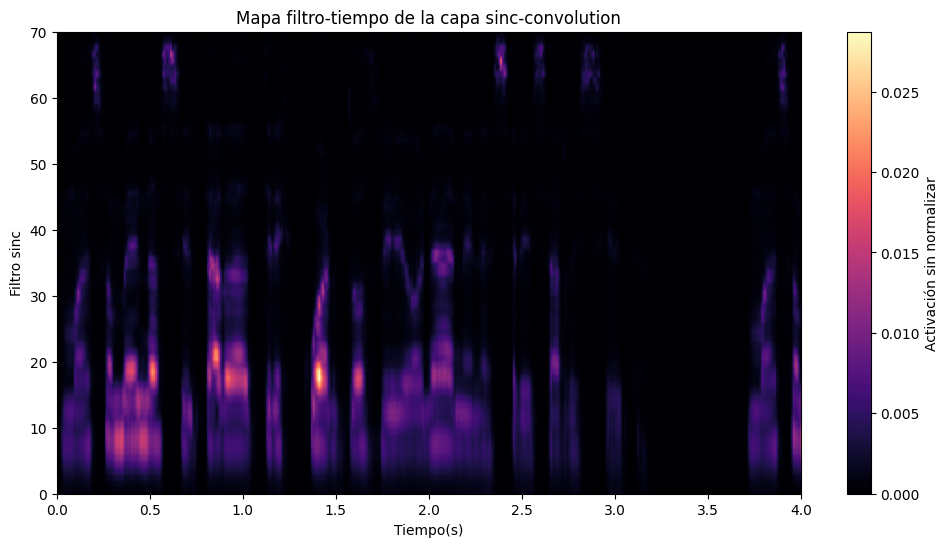

In [ ]:
filts = sc_out[0].abs().numpy()   #quitamos la primera dimensión y el resto a valor absoluto

filts_bin, filts_norm = group_frecs(filts)
plt.figure(figsize=(12, 6))
plt.imshow(
    filts_norm, 
    aspect="auto",
    origin="lower",
    cmap="magma", 
    extent=[0, 4.0, 0, filts.shape[0]]
)
plt.colorbar(label="Activación normalizada")
plt.xlabel("Tiempo(s)")
plt.ylabel("Filtro sinc")
plt.title("Mapa filtro-tiempo de la capa sinc-convolution")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(
    filts_bin, 
    aspect="auto",
    origin="lower",
    cmap="magma", 
    extent=[0, 4.0, 0, filts.shape[0]]
)
plt.colorbar(label="Activación sin normalizar")
plt.xlabel("Tiempo(s)")
plt.ylabel("Filtro sinc")
plt.title("Mapa filtro-tiempo de la capa sinc-convolution")
plt.show()

Funciones y variables comunes a ambos IG

In [32]:
def forward_logits(x):
    _, logits = model(x)
    return logits

#elegir la clase objetivo
with torch.no_grad():
    logits = forward_logits(t)
    prob = torch.softmax(logits, dim=1)
    target_class = int(torch.argmax(prob, dim=1).item())

#usamos de baseline un vector de ceros(silecio)
baseline = torch.zeros_like(t)

#asegurar modo evaluación
_ = model.eval()

Vamos a usar IG para mostrar que bandas de frecuencia del mapa de calor influyen más en la salida. Usamos LayerIntegratedGradients porque analizamos solo una capa concreta del modelo y nos devuelve la salidad en el mismo formato que la entrada, lo que nos permite representarla de la misma manera.

Usamos de baseline un vector silencio ya que la entrada a la capa es audio.

A diferencia de los mapas filtro-tiempo anteriores, aquí representamos las zonas que más contribuyen al logit final.

Como antes, representamos una gráfica normalizada para apreciar más detalle y una sin normalizar para ver el mapa puro.

Shape Layer IG: torch.Size([1, 70, 64472])
Convergence delta: tensor([-1.1767e-05])


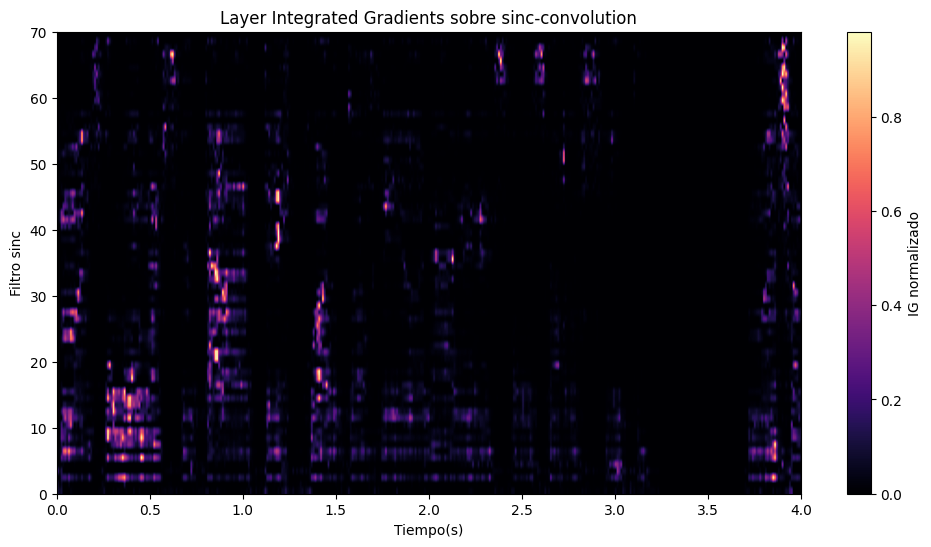

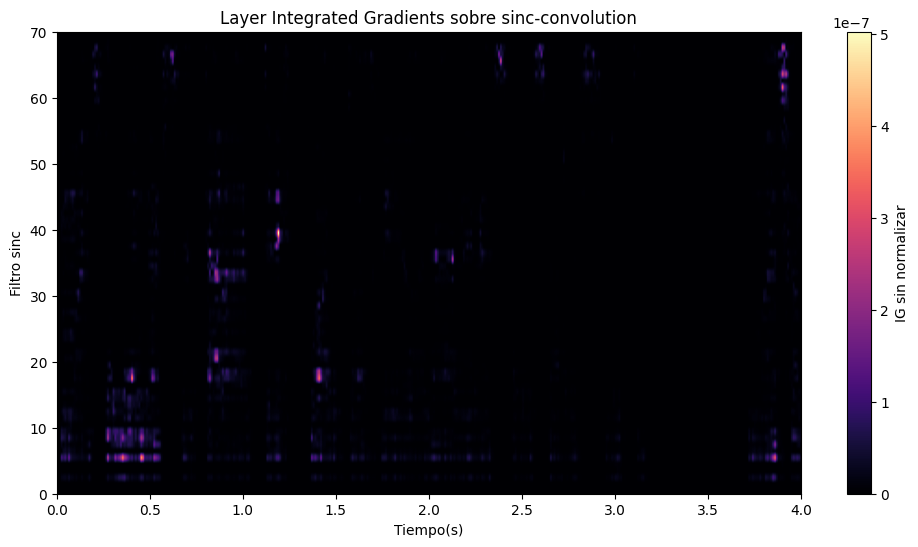

In [33]:
lig = LayerIntegratedGradients(forward_logits, model.conv_time) #actua sobre el primer arg y la capa el segundo arg
layer_attr, delta = lig.attribute(
    inputs=t,                        #audio de entrada
    baselines=baseline,              #silencio
    target=out["target_class"],      #clase objetivo
    n_steps=64,                      #saltos entre el baseline y la entrada real
    return_convergence_delta=True,   #medida de calidad de la explicación, cuanto más bajo mejor
    attribute_to_layer_input=False   #atribuir a la salida de la capa, no a su entrada
)

print("Shape Layer IG:", layer_attr.shape)
print("Convergence delta:", delta)

#quitar la dimensión de batch y pasar a numpy
M_ig = layer_attr[0].detach().cpu().numpy()

M_vis = np.abs(M_ig)

LIG_bin, LIG_norm = group_frecs(M_vis)

plt.figure(figsize=(12, 6))
plt.imshow(
    LIG_norm,
    aspect="auto",
    origin="lower",
    cmap="magma",
    extent=[0, 4.0, 0, LIG_norm.shape[0]]
)
plt.colorbar(label="IG normalizado")
plt.xlabel("Tiempo(s)")
plt.ylabel("Filtro sinc")
plt.title("Layer Integrated Gradients sobre sinc-convolution")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(
    LIG_bin,
    aspect="auto",
    origin="lower",
    cmap="magma",
    extent=[0, 4.0, 0, LIG_bin.shape[0]]
)
plt.colorbar(label="IG sin normalizar")
plt.xlabel("Tiempo(s)")
plt.ylabel("Filtro sinc")
plt.title("Layer Integrated Gradients sobre sinc-convolution")
plt.show()

Usando la atribución calculada de cada banda de frecuencia, lo usamos para hacer una curva temporal de importancia media de casa instante del audio.

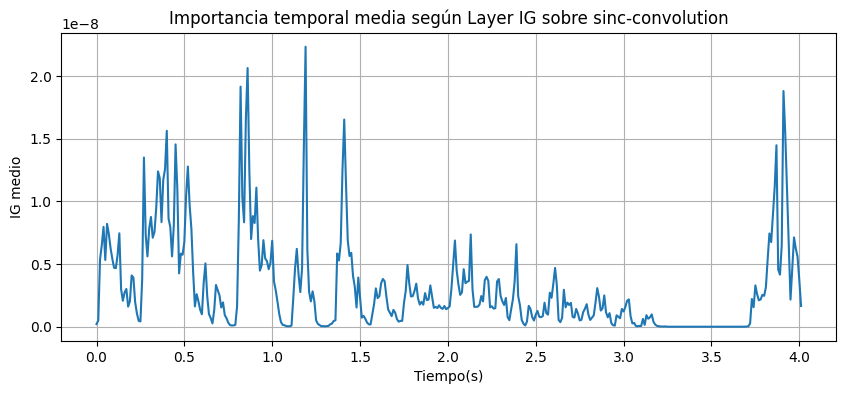

In [34]:
ig_time = LIG_bin.mean(axis=0)  #media de importancia de los filtros en cada instante
x_sec = np.arange(len(ig_time)) * (bin_ms / 1000)

plt.figure(figsize=(10, 4))
plt.plot(x_sec, ig_time)
plt.xlabel("Tiempo(s)")
plt.ylabel("IG medio")
plt.title("Importancia temporal media según Layer IG sobre sinc-convolution")
plt.grid(True)
plt.show()

Ahora, vamos aplicar IG sobre el audio crudo para obtener los momentos del audio que son más importantes según esta técnica

Shape IG audio: torch.Size([1, 64600])
Convergence delta: tensor([-1.1880e-05])


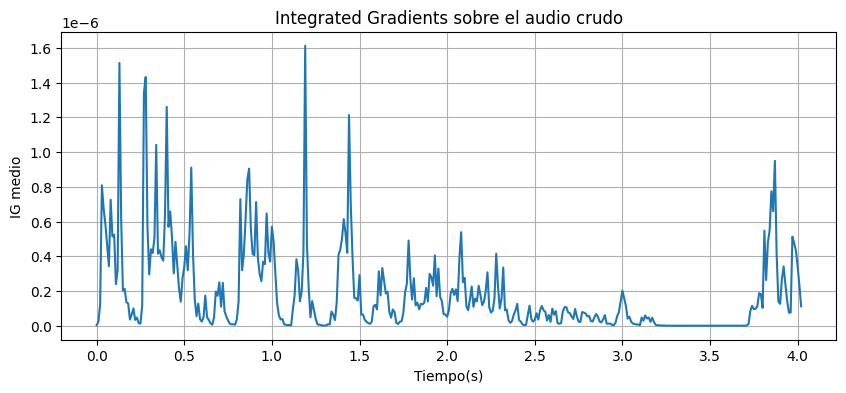

In [ ]:
ig = IntegratedGradients(forward_logits)
attrs, delta = ig.attribute(
    inputs=t,                       #audio de entrada
    baselines=baseline,             #silencio
    target=out["target_class"],     #clase objetivo
    n_steps=64,                     #saltos entre el baseline y la entrada real
    return_convergence_delta=True   #medida de calidad de la explicación, cuanto más bajo mejor
)

print("Shape IG audio:", attrs.shape)
print("Convergence delta:", delta)

#quitar la dimensión de batch y pasar a numpy
attr_audio = attrs[0].detach().cpu().numpy()   
attr_abs = np.abs(attr_audio)

#agrupamos temporalmente 
num_bloques = len(attr_abs) // bin_len    #num bloques
#primero reorganizamos con reshape y luego hacemos la media de cada bloque de 160 muestras(sr*bin_ms si se cambia)
attr_bin = attr_abs[:num_bloques * bin_len].reshape(num_bloques, bin_len).mean(axis=1) 

x_sec = np.arange(num_bloques) * bin_ms / 1000.0  

plt.figure(figsize=(10, 4))
plt.plot(x_sec, attr_bin)
plt.xlabel("Tiempo(s)")
plt.ylabel("IG medio")
plt.title("Integrated Gradients sobre el audio crudo")
plt.grid(True)
plt.show()

## RISE

Esta técnica consiste en ir generando máscaras aleatorias, multiplicar, en nuestro caso, por el audio y ver cuanto ha afectado al logit. Después, de hacer esto muchas veces, se empiezan a sacar patrones de que puntos del audio estaban visibles en los logits generados más altos.

In [ ]:
def generate_rise_mask(signal_len, grid_size=100, p_keep=0.5):
    #pequeña mascara de 0 y 1
    small_mask = (np.random.rand(grid_size) < p_keep).astype(np.float32)
    x_small = np.linspace(0, signal_len - 1, grid_size)
    x_full  = np.arange(signal_len)
    #hace un escalado entre los puntos de small mask para no generar picos y que las transiciones sean más suaves
    full_mask = np.interp(x_full, x_small, small_mask).astype(np.float32)
    return full_mask

def rise(x, target_class=None, n_masks=1000, grid_size=100, p_keep=0.5, score_mode="margin"):
    _,_,_,_, target_class = base_scores_logits(t, target_class)
    #acumulador del mapa
    saliency = np.zeros(long_audio, dtype=np.float64)
    #guardamos la secuencia de valores por si se quisiera mirar después
    all_scores = []
    for i in range(n_masks):
        mask = generate_rise_mask(
            signal_len=long_audio,
            grid_size=grid_size,
            p_keep=p_keep
        )
        # aplicar máscara al audio
        x_masked = (x * mask).astype(np.float32)

        #con el audio modificado, volvemos a calcular valores
        x_masked_pad = pad(x_masked, CUT).astype(np.float32)
        t_masked = torch.from_numpy(x_masked_pad).unsqueeze(0).to(device)

        _, logits_masked = ret_model(t_masked)

        spoof_logit_m = float(logits_masked[0, 0].item())
        bona_logit_m  = float(logits_masked[0, 1].item())
        margin_m = spoof_logit_m - bona_logit_m

        if score_mode == "margin":
            score = margin_m
        elif score_mode == "logit":
            score = float(logits_masked[0, target_class].item())
        else:
            raise ValueError("score_mode debe ser margin o logit")

        saliency += score * mask
        all_scores.append(score)
    #hacemos una media contando la probabilidad de que cada muestra sea visible
    saliency = saliency / (n_masks * p_keep)
    return saliency.astype(np.float32), np.array(all_scores, dtype=np.float32)

In [ ]:
saliency, scores = rise(
    x=x,
    target_class=None,      
    n_masks=1000,           #número de máscaras que se van a generar, es decir, iteraciones
    grid_size=100,          #tamaño de la máscara pequeña
    p_keep=0.5,             #probabilidad de que cada punto sea visible 
    score_mode="margin"     
)

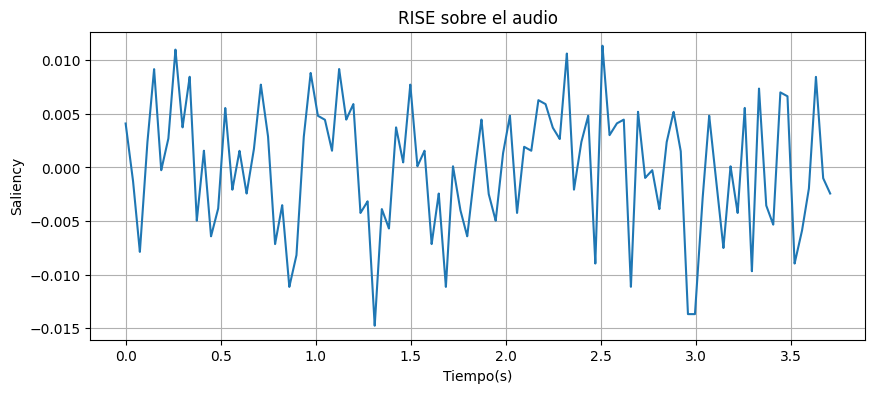

In [23]:
sal_center = saliency - np.mean(saliency) #centrar a cero y no en la diferencia entre clases original
x_sec = np.linspace(0, len(x) / sr, len(saliency))

plt.figure(figsize=(10, 4))
plt.plot(x_sec, sal_center)
plt.xlabel("Tiempo(s)")
plt.ylabel("Saliency")
plt.title("RISE sobre el audio")
plt.grid(True)
plt.show()

## SHAP
Como shap no se puede aplicar sobre aasist porque recibe un audio crudo en vez de caracteristicas y es un modelo muy costoso de llamar muchas veces, hemos intentado usar un modelo surrogate que imite la salida de aasist

# 1. IMPORTS

Hay alguno repetido con los imports del uso del modelo para poder ejecutar ambas cosas de forma independiente.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
import shap

# 2.RUTAS

In [2]:
FEATURES_CSV = "features.csv" 
AASIST_CSV   = "aasist_results2.csv"    
OUT_CSV      = "features_with_aasist.csv"

AASIST_SCORE_COL = "prob1_mean"  #nombre de la columna del aasist.csv

FILENAME_NORMALIZATION = "basename" #para el punto 4

# 3. Carga de csvs

In [3]:
feats = pd.read_csv(FEATURES_CSV)
aas  = pd.read_csv(AASIST_CSV)

# 4. Comparación de rutas y validación de la columna score

Normaliza las rutas de ambos csvs para que no haya errores por rutas distintas aunque se refieran al mismo audio y además luego facilita el nombrar archivos para la separación manual de los audios en train y test.

In [4]:
def normalize_fn(x: str) -> str:
    x = str(x)
    if FILENAME_NORMALIZATION == "basename": #solo el nombre del archivo
        return os.path.basename(x)
    if FILENAME_NORMALIZATION == "normpath": #toda la ruta
        return os.path.normpath(x)
    return x 

feats["filename"] = feats["filename"].apply(normalize_fn)
aas["filename"]  = aas["filename"].apply(normalize_fn)

#asegura que la columna de score existe
if AASIST_SCORE_COL not in aas.columns:
    raise ValueError(
        f"No encuentro la columna '{AASIST_SCORE_COL}' en {AASIST_CSV}. "
    )

# 5. Merge

El resultado es el csv de caracteristicas más la fila de score de aasist. Además, inner descarta archivos que no esten en ambos por si acaso.

In [5]:
df = feats.merge(aas[["filename", AASIST_SCORE_COL]], on="filename", how="inner")

#alguna comprobación para el merge
print("Filas features:", len(feats))
print("Filas aasist:", len(aas))
print("Filas merge:", len(df))

#el logit sirve para que los valores no estén cerrado entre [0,1] y crezca de manera más lineal
p = df[AASIST_SCORE_COL].clip(1e-6, 1-1e-6)
df["aasist_logit_bona"] = np.log(p/(1-p))
AASIST_SCORE_COL = "aasist_logit_bona"

#reordena para poner prob de bonafide al principio del csv
cols = df.columns.tolist()
new_order = ["filename", AASIST_SCORE_COL] + [c for c in cols if c not in ("filename", AASIST_SCORE_COL)]
df = df[new_order]

df.to_csv(OUT_CSV, index=False)
print(f"Guardado: {OUT_CSV}")

Filas features: 100
Filas aasist: 200
Filas merge: 100
Guardado: features_with_aasist.csv


# 6. Construir X e y(columna a imitar) y arreglo de formatos para evitar errores 

In [6]:
#sirve para quitar las columnas que no son features y no se quieren usar para entrenar el surrogate
DROP_COLS = ["filename", AASIST_SCORE_COL, "prob1_mean",] 

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()
y = df[AASIST_SCORE_COL].astype(float).values

#todo lo que no sea numérico lo convierte a NaN
X = X.apply(pd.to_numeric, errors="coerce")

# 7. División del dataset

Para train usamos los audios que también se usaron en un preentreno de aasist

In [7]:
test_filenames = {"E_10_G.wav", "E_10_N.wav", "E_19_G.wav","E_19_N.wav","E_20_G.wav","E_20_N.wav","E_29_G.wav","E_29_N.wav","E_30_G.wav","E_30_N.wav","E_39_G.wav","E_39_N.wav","E_40_G.wav","E_40_N.wav","E_49_G.wav","E_49_N.wav","E_50_G.wav","E_50_N.wav","E_9_G.wav","E_9_N.wav"} 

df["is_test"] = df["filename"].isin(test_filenames)

X_train = X[~df["is_test"]].copy()
y_train = y[~df["is_test"]]

X_test  = X[df["is_test"]].copy()
y_test  = y[df["is_test"]]

# 8. Entrenar el surrogate y fidelidad con aasist

R2 sirve para ver como de fiel es el surrogate, como vemos al entrenar si que tiene un valor cercano a 1 lo cual es aceptable pero en test tiene un valor que no refleja el modelo de aasist

In [8]:
sur = XGBRegressor(
    n_estimators=100, #número de árboles, subirlo puede llevar a sobreajuste
    max_depth=3, #prof máxima de cada árbol
    learning_rate=0.05, #le peso de cada árbol nuevo
    subsample=0.7, #% de audios que usa cada árbol
    colsample_bytree=0.7, #% de features que usa cada árbol
    reg_lambda=10.0, #penaliza pesos grandes
    reg_alpha=1.0, #penaliza pesos pequeños
    min_child_weight=5, #controla la creación de nodos nuevos
    gamma=0.5, #coste mínimo para hacer un split
    random_state=0 #aleatoriedad 
)
sur.fit(X_train, y_train)

train_pred = sur.predict(X_train)
test_pred  = sur.predict(X_test)
print("R2 train:", r2_score(y_train, train_pred))
print("R2 test :", r2_score(y_test, test_pred))

R2 train: 0.7512567390989654
R2 test : 0.039327820772911304


# 9. Aplicar shap

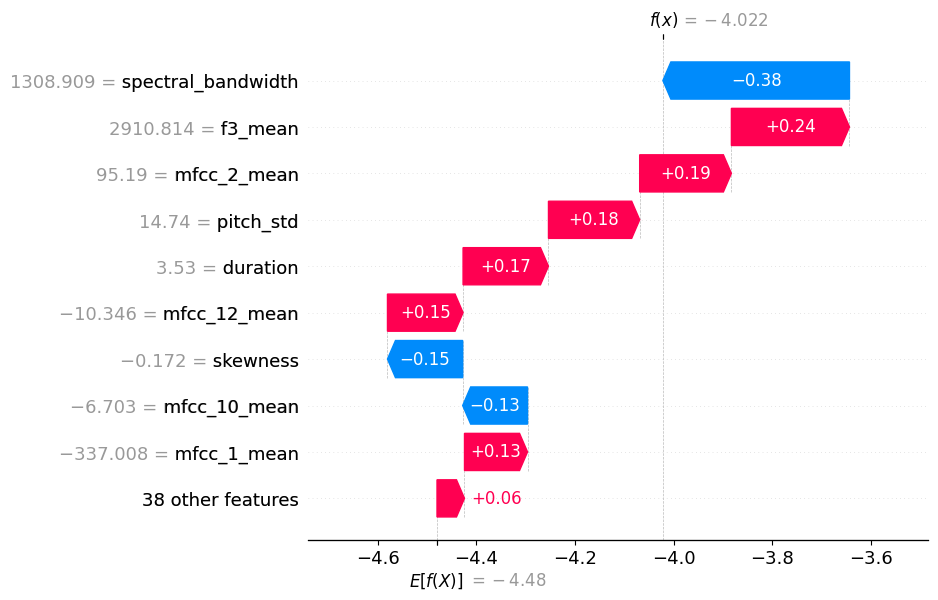

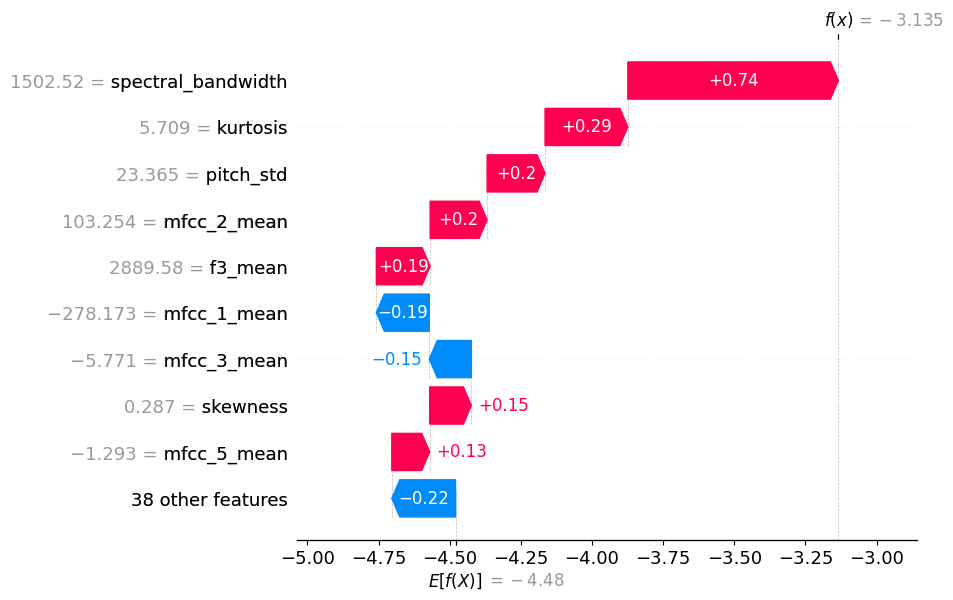

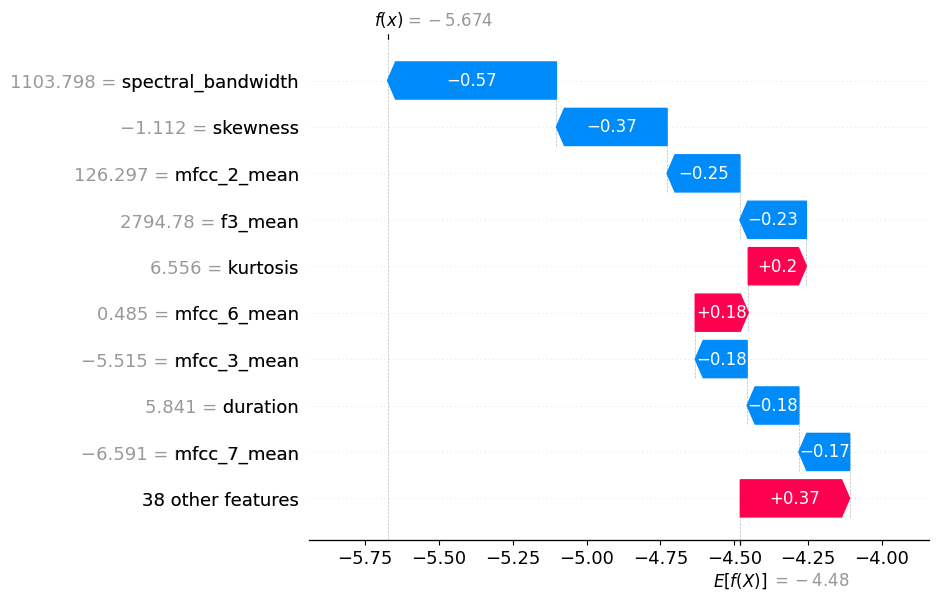

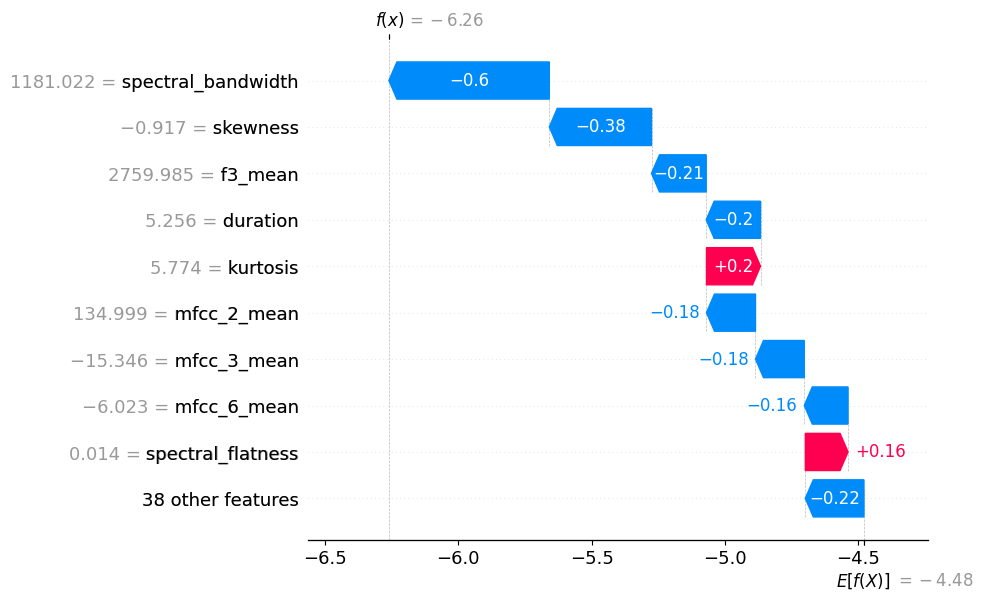

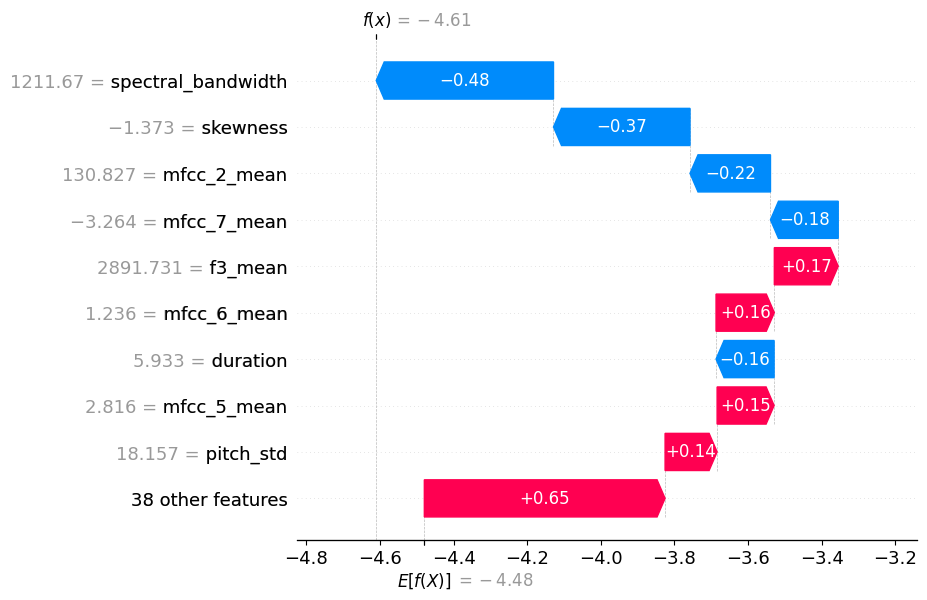

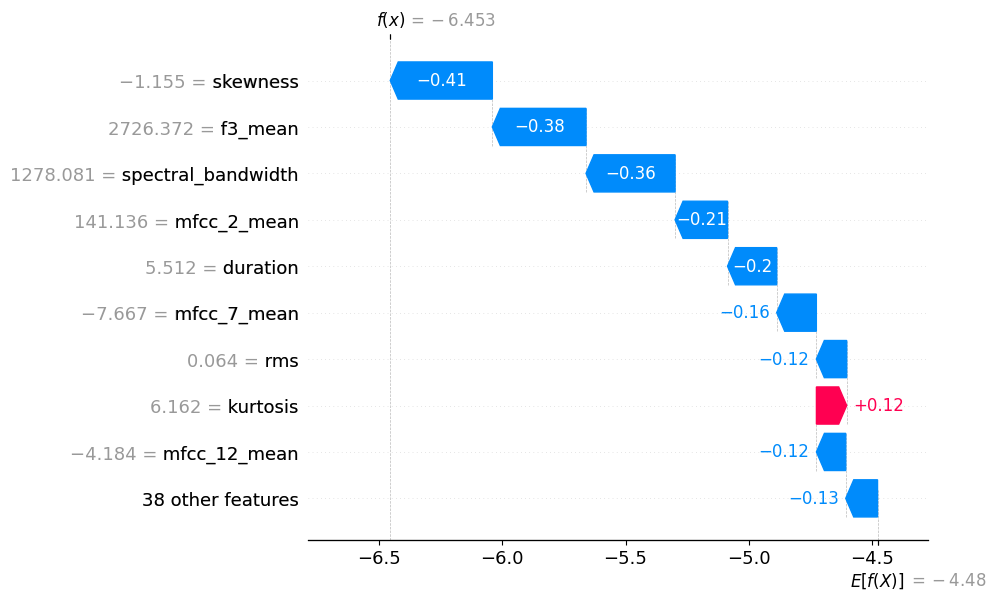

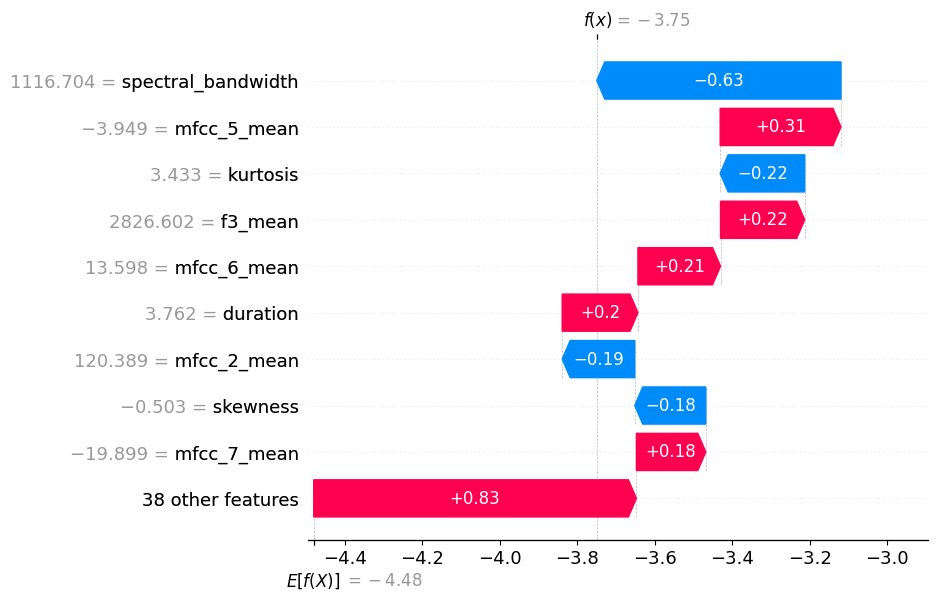

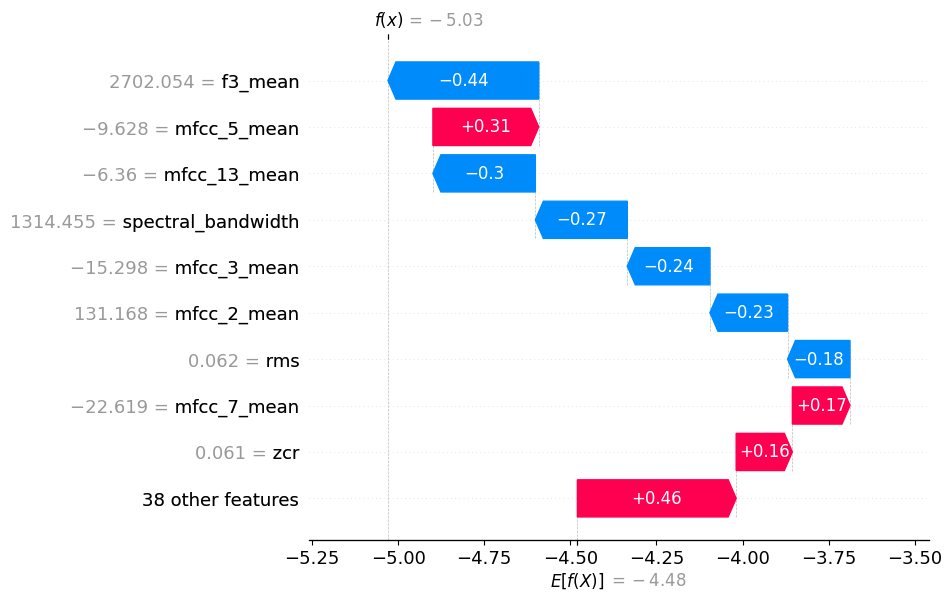

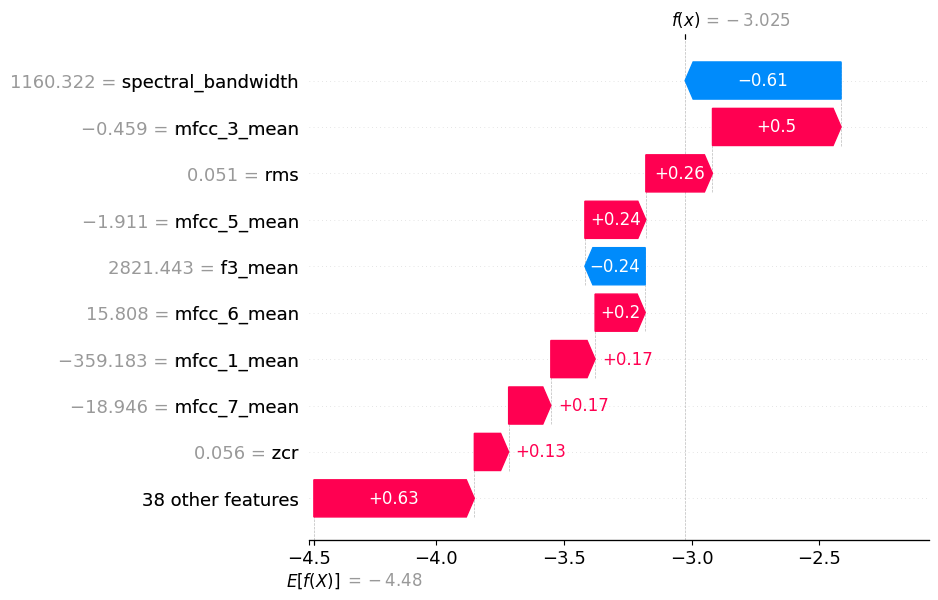

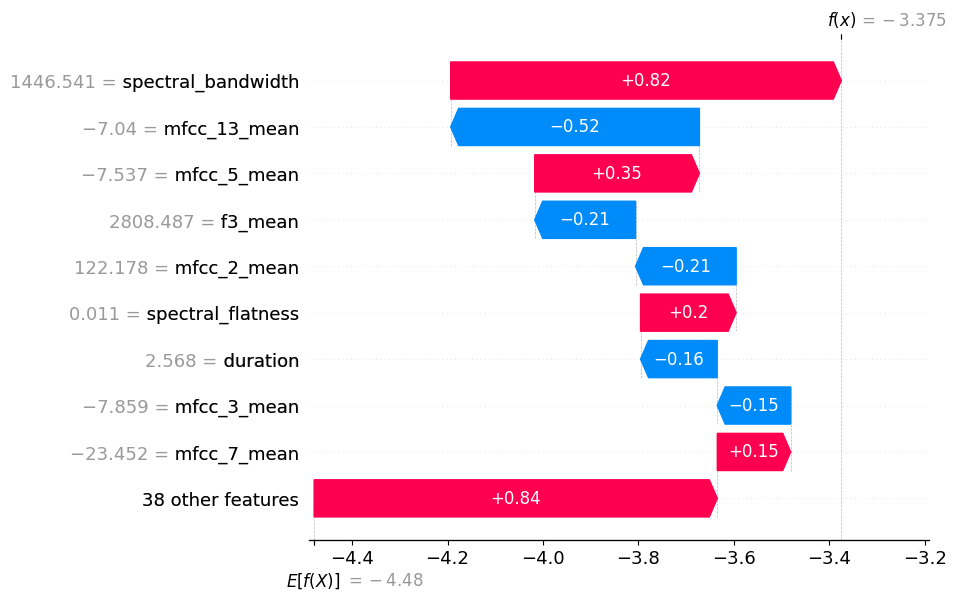

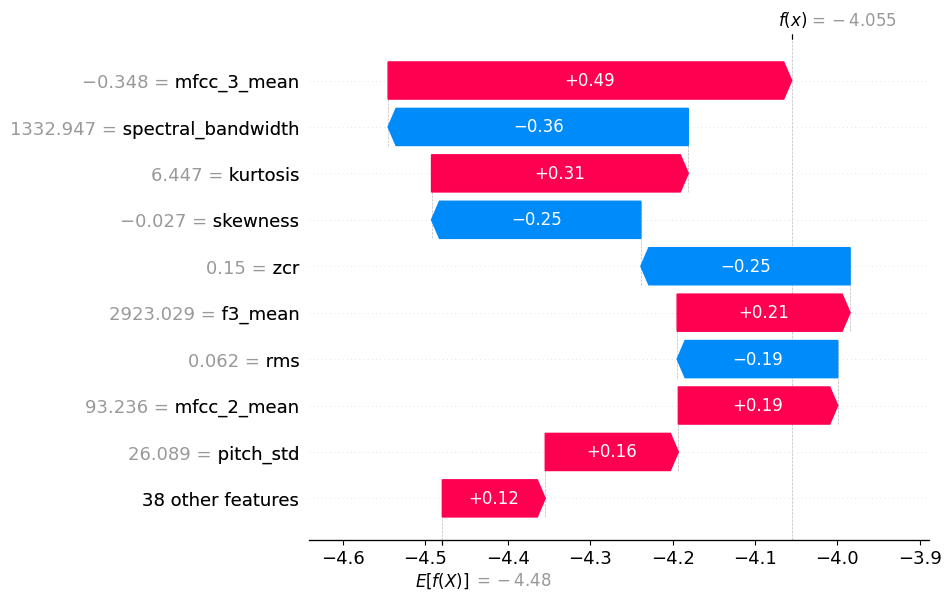

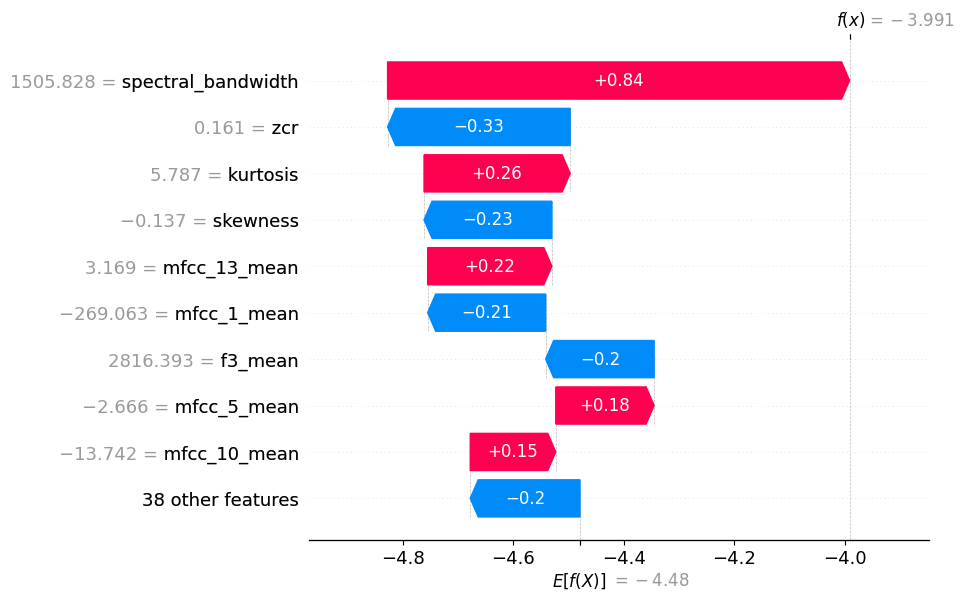

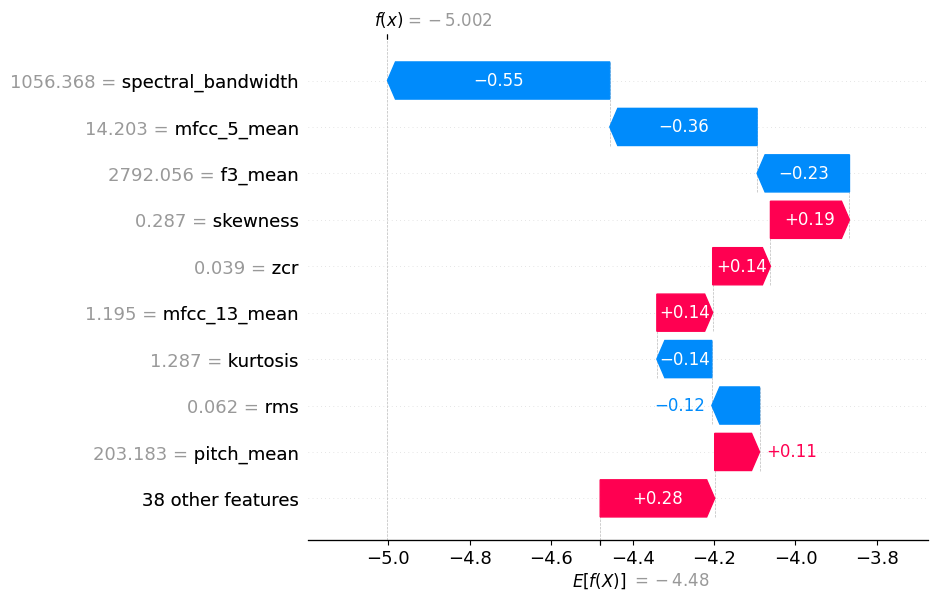

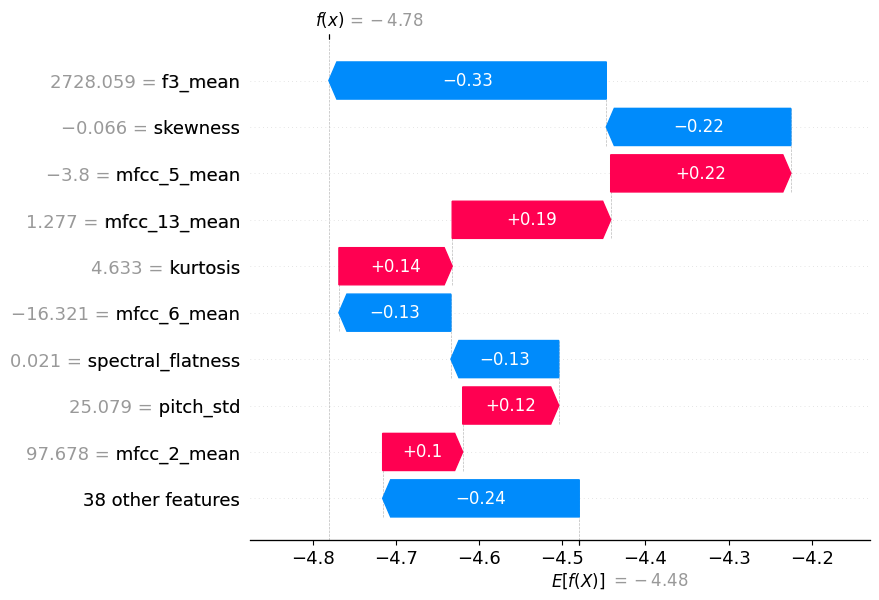

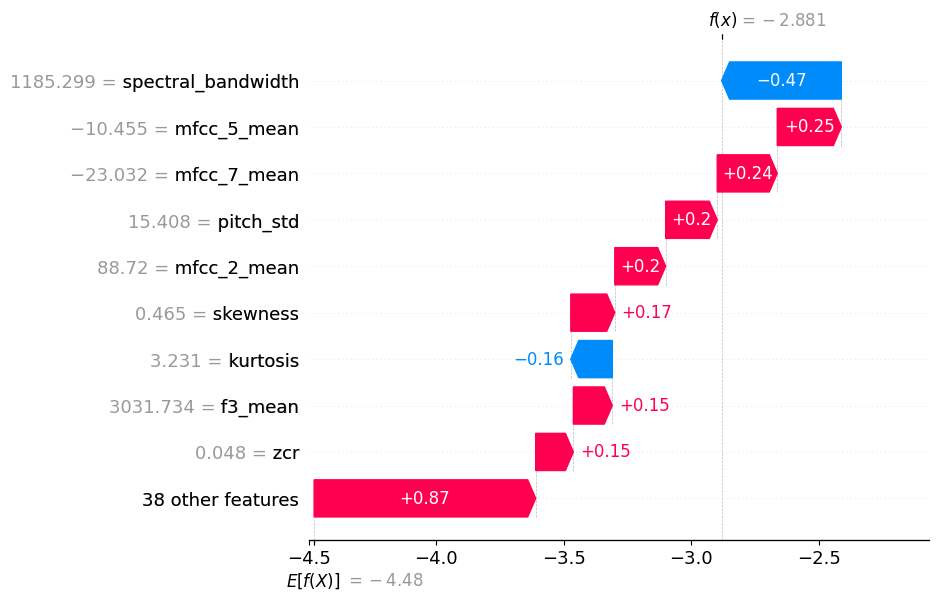

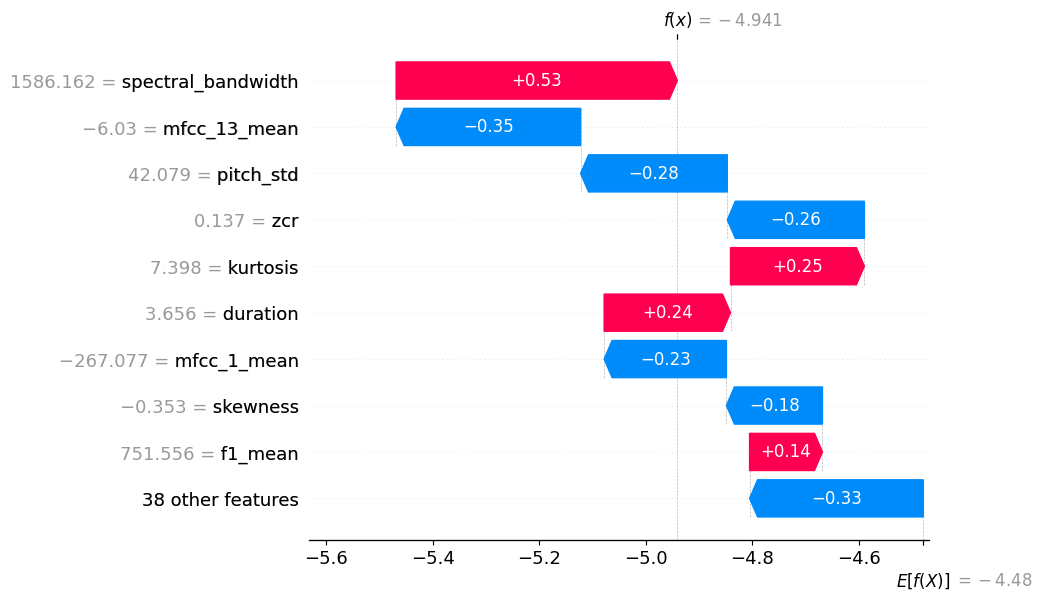

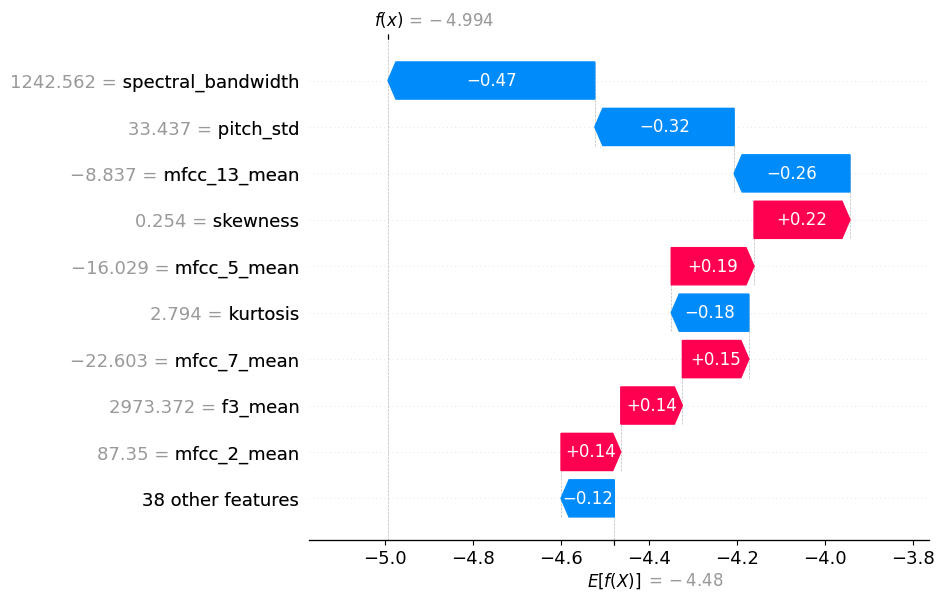

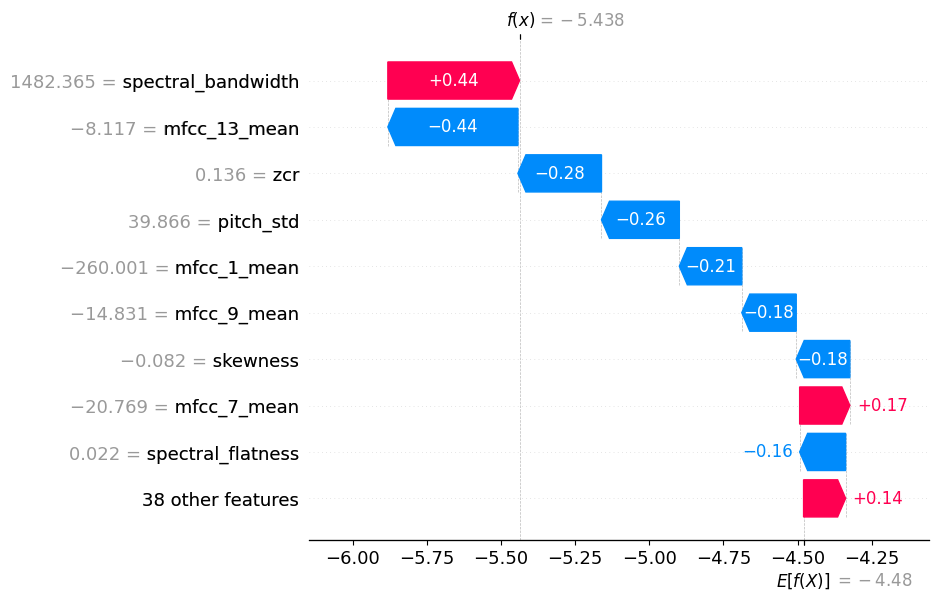

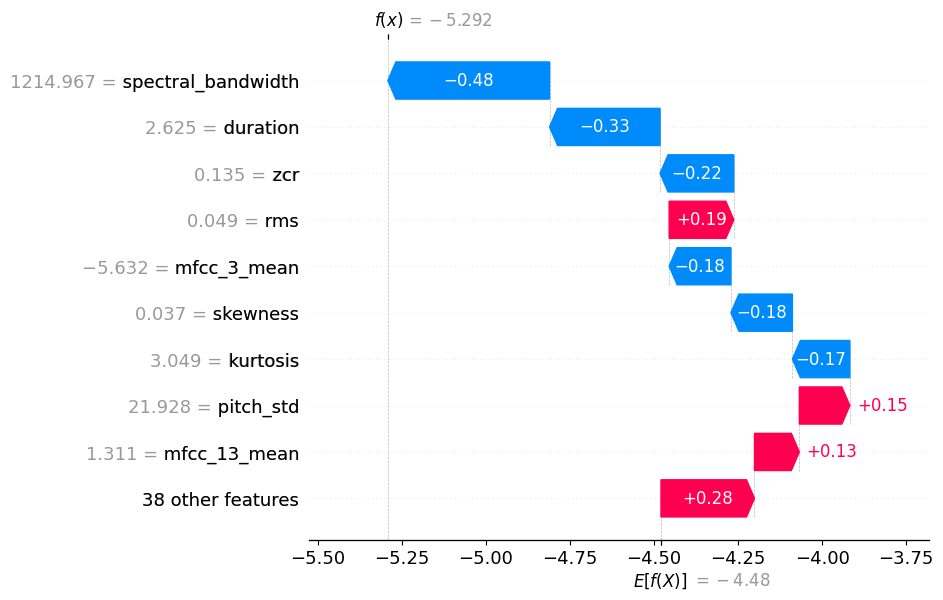

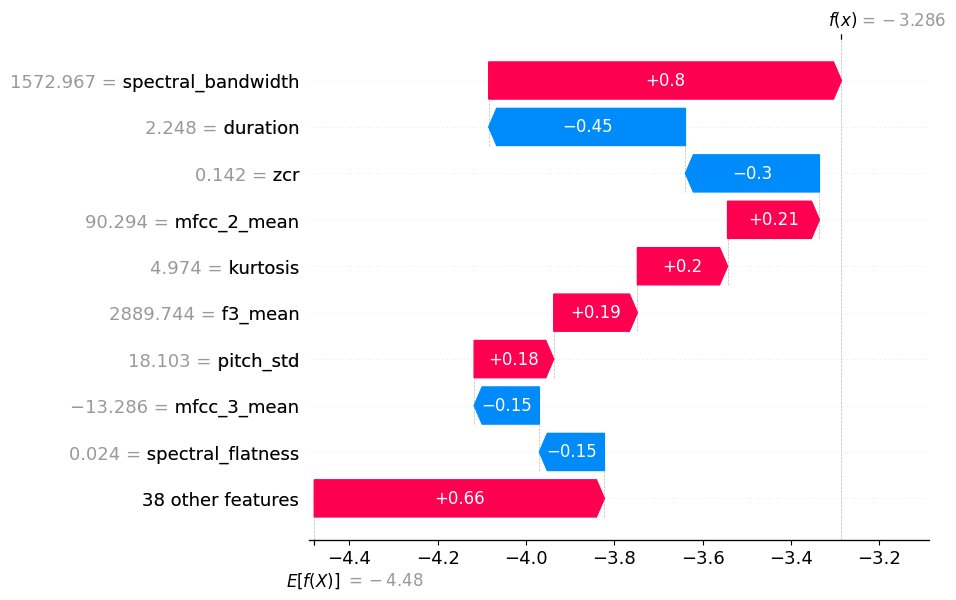

In [9]:
explainer = shap.Explainer(sur, X_train)
shap_values = explainer(X_test)

for i in range(20):
    shap.plots.waterfall(shap_values[i])